# 03 — Modelovanie

Notebook nadväzuje na **02_Extrakcia_zo_stlpcov.ipynb**. Obsahuje pôvodné experimentálne bunky modelovania, imputácie a EDA okolo indexov.


### Použité knižnice

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import os.path
from datetime import datetime
from matplotlib import pyplot as plt
from typing import Union, List, Dict, Tuple
import unidecode
import re
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment
from collections import Counter
from itertools import combinations
from IPython.display import display
import json
import pyarrow as pa
import pyarrow.parquet as pq

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

## 1. Načítanie príznakov z notebooku 02

### 1.1 Pomocné funkcie pre robustný I/O do parquet

`load_df_from_parquet` číta parquet uložený funkciou `export_df_to_parquet` z notebooku 02 a obnoví Python listy v stĺpcoch ako sú saturácie a teploty.

In [12]:

def export_df_to_parquet(df: pd.DataFrame, path: str) -> None:
    df_out = df.copy()
    serialized_cols = []

    for col in df_out.select_dtypes(include="object").columns:
        sample = df_out[col].dropna().head(100)
        if any(isinstance(x, (list, dict, tuple, set)) for x in sample):
            df_out[col] = df_out[col].apply(
                lambda x: json.dumps(
                    list(x) if isinstance(x, (tuple, set)) else x,
                    default=str,
                )
                if isinstance(x, (list, dict, tuple, set))
                else (None if pd.isna(x) else x)
            )
            serialized_cols.append(col)

    table = pa.Table.from_pandas(df_out, preserve_index=False)
    if serialized_cols:
        existing_meta = table.schema.metadata or {}
        new_meta = dict(existing_meta)
        new_meta[b"list_json_cols"] = json.dumps(serialized_cols).encode("utf-8")
        table = table.replace_schema_metadata(new_meta)

    pq.write_table(table, path)

    print(f"Exportované do parquet: {path}")
    print(f"   Tvar: {df_out.shape}")
    if serialized_cols:
        print(f"   JSON-serializované list-stĺpce ({len(serialized_cols)}): {serialized_cols}")


def load_df_from_parquet(path: str) -> pd.DataFrame:
    table = pq.read_table(path)
    df = table.to_pandas()

    meta = table.schema.metadata or {}
    if b"list_json_cols" in meta:
        list_cols = json.loads(meta[b"list_json_cols"].decode("utf-8"))
        for col in list_cols:
            if col in df.columns:
                df[col] = df[col].apply(
                    lambda x: json.loads(x) if isinstance(x, str) and x else x
                )
        print(f"   Deserializované list-stĺpce ({len(list_cols)}): {list_cols}")

    print(f"Načítané z parquet: {path}")
    print(f"   Tvar: {df.shape}")
    return df


In [13]:
# Použitie funkcie load_df_from_parquet (deserializuje list-stĺpce späť)
df_f = load_df_from_parquet('02_extrakcia_zo_stlpcov.parquet')

Načítané z parquet: 02_extrakcia_zo_stlpcov.parquet
   Tvar: (3848, 671)


## 2. Príprava modelovacieho dataframu

Z `df_f` sa vytvorí pracovná kópia `df_model` ktorá slúži ako základ pre všetky
modelovacie experimenty. Vypíše sa základný prehľad datasetu — počet pacientov,
počet príznakov, typy stĺpcov a súhrnná štatistika numerických premenných
(priemer, medián, min/max, štandardná odchýlka).

In [14]:
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost nie je nainštalovaný. Inštalácia: pip install catboost")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost nie je nainštalovaný. Inštalácia: pip install xgboost")

RANDOM_STATE = 42
N_SPLITS = 5


#  Imputačné stratégie použité vo finálnom modelovaní
IMPUTATION_STRATEGIES = {
    "simple_median": "Numerické = medián, kategorické = najčastejšia hodnota",
    "knn": "Numerické = KNNImputer, kategorické = najčastejšia hodnota"
}


def build_numeric_transformer(imputation_strategy: str = "simple_median") -> Pipeline:
    """Vytvorí numerický preprocessing podľa zvolenej imputácie."""

    if imputation_strategy == "simple_median":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True))
        ])

    if imputation_strategy == "knn":
        return Pipeline(steps=[
            # StandardScaler ignoruje NaN pri fitovaní; KNNImputer následne doplní hodnoty.
            ("scaler", StandardScaler()),
            ("imputer", KNNImputer(
                n_neighbors=5,
                weights="distance",
                keep_empty_features=True
            ))
        ])

    raise ValueError(
        f"Neznáma imputation_strategy: {imputation_strategy}. "
        f"Povolené stratégie: {list(IMPUTATION_STRATEGIES.keys())}"
    )


def build_categorical_transformer() -> Pipeline:
    """Kategorické premenné: najčastejšia hodnota + one-hot encoding."""
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])


def split_feature_types(X: pd.DataFrame) -> tuple[list, list]:
    """Rozdelí vstupné premenné na kategorické a numerické."""
    categorical_cols = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_cols = [
        col for col in X.columns
        if col not in categorical_cols
    ]

    return categorical_cols, numeric_cols


def build_preprocessor(
    X: pd.DataFrame,
    imputation_strategy: str = "simple_median"
) -> ColumnTransformer:

    categorical_cols, numeric_cols = split_feature_types(X)

    return ColumnTransformer(
        transformers=[
            ("cat", build_categorical_transformer(), categorical_cols),
            ("num", build_numeric_transformer(imputation_strategy), numeric_cols)
        ],
        remainder="drop"
    )


def build_tree_pipeline(
    X: pd.DataFrame,
    model_type: str = "hgb",
    imputation_strategy: str = "simple_median"
) -> Pipeline:
    preprocessor = build_preprocessor(
        X,
        imputation_strategy=imputation_strategy
    )

    if model_type == "hgb":
        # HistGradientBoosting vie pracovať aj s NaN, ale v tomto experimente
        # ho kvôli porovnateľnosti trénujeme s rovnakou imputáciou ako ostatné modely.
        model = HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            class_weight="balanced"
        )

    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        )

    else:
        raise ValueError(f"Neznámy model_type: {model_type}")

    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])



#  Pipeline pre CatBoost a XGBoost
# ============================================================

def build_boosting_pipeline(
    X: pd.DataFrame,
    model_type: str,
    imputation_strategy: str = "simple_median"
) -> Pipeline:

    preprocessor = build_preprocessor(
        X,
        imputation_strategy=imputation_strategy
    )

    if model_type == "catboost":
        model = CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="MultiClass",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False
        )

    elif model_type == "xgboost":
        model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    else:
        raise ValueError(f"Neznámy model_type: {model_type}")

    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])


In [15]:

df_model = df_f.copy()
print("ZÁKLADNÝ PREHĽAD DATAFRAME df_f")

# Rozmery dataframe
print(f"Počet riadkov: {df_model.shape[0]}")
print(f"Počet stĺpcov: {df_model.shape[1]}")

print("\nTYPY STĹPCOV")
print(df_model.dtypes.value_counts())

print("\nINFO")
df_model.info()


numeric_cols = df_f.select_dtypes(include=["number"]).columns.tolist()

numeric_summary = df_f[numeric_cols].describe().T.round(3)

numeric_summary

ZÁKLADNÝ PREHĽAD DATAFRAME df_f
Počet riadkov: 3848
Počet stĺpcov: 671

TYPY STĹPCOV
float64           281
category          188
datetime64[ns]     96
object             71
bool               21
int64              12
category            1
category            1
Name: count, dtype: int64

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3848 entries, 0 to 3847
Columns: 671 entries, Poradie to no_sat
dtypes: bool(21), category(190), datetime64[ns](96), float64(281), int64(12), object(71)
memory usage: 14.3+ MB


,count,mean,std,min,25%,50%,75%,max
Poradie,3848.0,1924.500,1110.966,1.000,962.750,1924.500,2886.250,3848.000
Vek,3848.0,64.904,15.729,19.000,54.000,67.000,77.000,100.000
vlna,3848.0,2.527,1.218,1.000,1.000,2.000,4.000,4.000
Kód príjmu,3848.0,1.018,0.186,1.000,1.000,1.000,1.000,3.000
Kód prepustenia,3848.0,2.133,1.818,1.000,1.000,1.000,3.000,7.000
...,...,...,...,...,...,...,...,...
IROD_satO2_prva,2313.0,9.894,28.362,0.008,2.698,5.014,9.471,792.220
CLIF_COVID_prva,3563.0,43.118,273.632,0.013,2.426,5.709,15.781,7855.623
sat_bez_o2_med,2750.0,91.880,6.738,44.000,90.000,94.000,96.000,100.000
sat_s_o2_med,2370.0,92.177,6.132,47.000,90.000,94.000,96.000,100.000


### 2.1 Definícia cieľovej premennej

Z pôvodného stĺpca `Stav prepustenia` sa odvodzujú dve verzie cieľovej premennej:

- `target_3` — tri triedy: `prepustenie`, `preložený` (vrátane ARO/OAIM), `exitus`
- `target_4` — štyri triedy: `prepustenie`, `preložený`, `ARO/OAIM`, `exitus`

Pre modelovanie sa primárne používa `target_3` — zlúčenie ARO/OAIM s preloženými
znižuje triednu nerovnováhu a zjednodušuje klasifikačnú úlohu.

In [16]:
df_model["target_3"] = df_model["Stav prepustenia"].replace({
    "prepustenie amb. star.": "prepustenie",
    "preložený": "preložený",
    "ARO/OAIM": "preložený",
    "exitus letalis": "exitus"
})

print("Target 3 skupiny:")
print(df_model["target_3"].value_counts(dropna=False))
print(df_model["target_3"].value_counts(normalize=True, dropna=False).round(3))



df_model["target_4"] = df_model["Stav prepustenia"].replace({
    "prepustenie amb. star.": "prepustenie",
    "preložený": "preložený",
    "ARO/OAIM": "ARO/OAIM",
    "exitus letalis": "exitus"
})

print("Target 4 skupiny:")
print(df_model["target_4"].value_counts(dropna=False))
print(df_model["target_4"].value_counts(normalize=True, dropna=False).round(3))


Target 3 skupiny:
target_3
prepustenie    2558
preložený       858
exitus          432
Name: count, dtype: int64
target_3
prepustenie    0.665
preložený      0.223
exitus         0.112
Name: proportion, dtype: float64
Target 4 skupiny:
target_4
prepustenie    2558
preložený       786
exitus          432
ARO/OAIM         72
Name: count, dtype: int64
target_4
prepustenie    0.665
preložený      0.204
exitus         0.112
ARO/OAIM       0.019
Name: proportion, dtype: float64


In [17]:
#  Kontrola prítomnosti komorbidít a vakcinačných premenných
expected_feature_cols = [
    "Hypertenzia",
    "Diabetes mellitus",
    "Kardiovaskulárne ochorenia",
    "Chronické respiračné ochorenia",
    "Pečeňové ochorenia",
    "Onkologické ochorenia",
    "Imunosupresia",
    "Vakcinácia",
    "Typ vakcíny",
    "Počet dávok"
]

existing_feature_cols = [
    col for col in expected_feature_cols
    if col in df_f.columns
]

missing_feature_cols = [
    col for col in expected_feature_cols
    if col not in df_f.columns
]

print("Dostupné stĺpce vo df_f:")
print(existing_feature_cols)

print("\nChýbajúce stĺpce vo df_f:")
print(missing_feature_cols)

print("\nPočet dostupných z očakávaných stĺpcov:")
print(f"{len(existing_feature_cols)} / {len(expected_feature_cols)}")

Dostupné stĺpce vo df_f:
['Hypertenzia', 'Diabetes mellitus', 'Kardiovaskulárne ochorenia', 'Chronické respiračné ochorenia', 'Pečeňové ochorenia', 'Onkologické ochorenia', 'Imunosupresia', 'Vakcinácia', 'Typ vakcíny', 'Počet dávok']

Chýbajúce stĺpce vo df_f:
[]

Počet dostupných z očakávaných stĺpcov:
10 / 10


### 2.2 Definícia príznakových setov

Príznaky sa rozdeľujú do dvoch základných baseline skupín:

- **Admission** — obsahuje iba hodnoty namerané pri prijatí pacienta (`prva_hodnota`),
  čo zodpovedá reálnemu klinickému scenáru kde sú dostupné len vstupné merania
- **Mixed** — kombinuje prvú aj poslednú nameranú hodnotu každého parametra,
  čo poskytuje bohatší obraz o priebehu hospitalizácie

Na týchto dvoch základoch sa stavajú rozšírené sety postupným pridávaním
príznakových skupín — indexy (NLR, SII...), referenčné statusy (`low/normal/high`),
saturácie O₂, teploty, symptómy a demografické údaje.

Celkovo je definovaných 14 príznakových setov pre každý režim.

In [18]:
# Odvodené indexy
index_cols = [
    col for col in df_model.columns
    if (
        col.endswith("_prva")
        or col.endswith("_mon_prva")
        or col.endswith("_dNLR_prva")
    )
]

# Saturácie
sat_cols = [
    col for col in df_model.columns
    if (
        col.startswith("sat_")
        or col.startswith("has_sat")
        or col == "no_sat"
    )
]

# Teploty
temp_cols = [
    col for col in df_model.columns
    if (
        col.startswith("temp_")
        or col in ["teploty", "has_temp", "febrilita", "hyperpyrexia"]
    )
]

# Symptómy
symptom_cols = [
    col for col in [
        "kasel",
        "hnacka",
        "triaska_zimnica",
        "zvracanie",
        "nechutenstvo"
    ]
    if col in df_model.columns
]

# Komorbidity
comorbidity_cols = [
    col for col in [
        "Hypertenzia",
        "Diabetes mellitus",
        "Kardiovaskulárne ochorenia",
        "Chronické respiračné ochorenia",
        "Pečeňové ochorenia",
        "Onkologické ochorenia",
        "Imunosupresia"
        #"Počet komorbidít"

    ]
    if col in df_model.columns
]

# Vakcinácia
vaccination_cols = [
    col for col in [
        "Vakcinácia",
        "Typ vakcíny",
        "Počet dávok"
    ]
    if col in df_model.columns
]

In [19]:
feature_group_summary = pd.DataFrame({
    "Skupina": [
        "index_cols",
        "sat_cols",
        "temp_cols",
        "symptom_cols",
        "comorbidity_cols",
        "vaccination_cols"
    ],
    "Počet premenných": [
        len(index_cols),
        len(sat_cols),
        len(temp_cols),
        len(symptom_cols),
        len(comorbidity_cols),
        len(vaccination_cols)
    ]
})

feature_group_summary

,Skupina,Počet premenných
0,index_cols,36
1,sat_cols,16
2,temp_cols,8
3,symptom_cols,5
4,comorbidity_cols,7
5,vaccination_cols,3


In [20]:
demographic_cols = [
    col for col in ["Vek", "Pohlavie"]
    if col in df_model.columns
]

exclude_from_lab_keywords = [
    "datum",
    "dátum",
    "status",
    "ref",
    "refer",
    "povol",
    "interval"
]

# Bezpečnejšia verzia: iba prvé dostupné hodnoty
lab_first_cols = [
    col for col in df_model.columns
    if col.endswith("_prva_hodnota")
    and not any(key in col.lower() for key in exclude_from_lab_keywords)
]

# Mixed verzia: viac transformovaných laboratórnych hodnôt
lab_mixed_cols = [
    col for col in df_model.columns
    if (
        col.endswith("_prva_hodnota")
        or col.endswith("_posledna_hodnota")
        or col.endswith("_minimum")
        or col.endswith("_maximum")
        or col.endswith("_median")
    )
    and not any(key in col.lower() for key in exclude_from_lab_keywords)
]

baseline_first_cols = demographic_cols + lab_first_cols
baseline_mixed_cols = demographic_cols + lab_mixed_cols

# Odstránenie duplicít
baseline_first_cols = list(dict.fromkeys(baseline_first_cols))
baseline_mixed_cols = list(dict.fromkeys(baseline_mixed_cols))

print(f"Demografické premenné: {len(demographic_cols)}")
print(f"Lab first-only premenné: {len(lab_first_cols)}")
print(f"Lab mixed premenné: {len(lab_mixed_cols)}")
print(f"Baseline first-only spolu: {len(baseline_first_cols)}")
print(f"Baseline mixed spolu: {len(baseline_mixed_cols)}")

Demografické premenné: 2
Lab first-only premenné: 47
Lab mixed premenné: 235
Baseline first-only spolu: 49
Baseline mixed spolu: 237


In [21]:
mixed_extra_cols = [
    col for col in baseline_mixed_cols
    if col not in baseline_first_cols
]

print(f"Premenné navyše v mixed-data verzii: {len(mixed_extra_cols)}")
mixed_extra_cols[:50]

Premenné navyše v mixed-data verzii: 188


['S-Bil-T_minimum',
 'S-Bil-T_median',
 'S-Bil-T_maximum',
 'S-Bil-T_posledna_hodnota',
 'S-AST_minimum',
 'S-AST_median',
 'S-AST_maximum',
 'S-AST_posledna_hodnota',
 'S-ALT_minimum',
 'S-ALT_median',
 'S-ALT_maximum',
 'S-ALT_posledna_hodnota',
 'S-GMT_minimum',
 'S-GMT_median',
 'S-GMT_maximum',
 'S-GMT_posledna_hodnota',
 'S-ALP_minimum',
 'S-ALP_median',
 'S-ALP_maximum',
 'S-ALP_posledna_hodnota',
 'S-Chol_minimum',
 'S-Chol_median',
 'S-Chol_maximum',
 'S-Chol_posledna_hodnota',
 'S-CB_minimum',
 'S-CB_median',
 'S-CB_maximum',
 'S-CB_posledna_hodnota',
 'S-Na_minimum',
 'S-Na_median',
 'S-Na_maximum',
 'S-Na_posledna_hodnota',
 'S-K_minimum',
 'S-K_median',
 'S-K_maximum',
 'S-K_posledna_hodnota',
 'S-CL_minimum',
 'S-CL_median',
 'S-CL_maximum',
 'S-CL_posledna_hodnota',
 'S-IgG_minimum',
 'S-IgG_median',
 'S-IgG_maximum',
 'S-IgG_posledna_hodnota',
 'S-IgA_minimum',
 'S-IgA_median',
 'S-IgA_maximum',
 'S-IgA_posledna_hodnota',
 'S-Ig M_minimum',
 'S-Ig M_median']

In [22]:
FEATURE_SETS = {
    "baseline_first_only": baseline_first_cols,
    "baseline_mixed": baseline_mixed_cols,

    "first_plus_indexes": (
        baseline_first_cols + index_cols
    ),

    "mixed_plus_indexes": (
        baseline_mixed_cols + index_cols
    ),

    "first_plus_extracted": (
        baseline_first_cols
        + symptom_cols
        + temp_cols
        + sat_cols
        + comorbidity_cols
        + vaccination_cols
    ),

    "mixed_plus_extracted": (
        baseline_mixed_cols
        + symptom_cols
        + temp_cols
        + sat_cols
        + comorbidity_cols
        + vaccination_cols
    ),

    "first_all_features": (
        baseline_first_cols
        + index_cols
        + symptom_cols
        + temp_cols
        + sat_cols
        + comorbidity_cols
        + vaccination_cols
    ),

    "mixed_all_features": (
        baseline_mixed_cols
        + index_cols
        + symptom_cols
        + temp_cols
        + sat_cols
        + comorbidity_cols
        + vaccination_cols
    ),
}

FEATURE_SETS = {
    name: list(dict.fromkeys(cols))
    for name, cols in FEATURE_SETS.items()
}

feature_set_summary = pd.DataFrame({
    "feature_set": FEATURE_SETS.keys(),
    "n_features": [len(cols) for cols in FEATURE_SETS.values()]
})

feature_set_summary


,feature_set,n_features
0,baseline_first_only,49
1,baseline_mixed,237
2,first_plus_indexes,85
3,mixed_plus_indexes,273
4,first_plus_extracted,88
5,mixed_plus_extracted,276
6,first_all_features,121
7,mixed_all_features,309


In [23]:
# Prvé hodnoty – ref statusy
ref_status_first_cols = [
    col for col in df_model.columns
    if col.endswith("_prva_ref_status")
]

# Prvé hodnoty – allowed statusy
allowed_status_first_cols = [
    col for col in df_model.columns
    if col.endswith("_prva_allowed_status")
]

# Posledné hodnoty – ref statusy
ref_status_last_cols = [
    col for col in df_model.columns
    if col.endswith("_posledna_ref_status")
]

# Posledné hodnoty – allowed statusy
allowed_status_last_cols = [
    col for col in df_model.columns
    if col.endswith("_posledna_allowed_status")
]

# Súhrnné počty abnormalít
abnormal_count_cols = [
    col for col in df_model.columns
    if col in [
        "Pocet_abn_prva_ref",
        "Pocet_abn_prva_allowed",
        "Pocet_abn_posledna_ref",
        "Pocet_abn_posledna_allowed",
    ]
]

ref_allowed_first_cols = (
    ref_status_first_cols
    + allowed_status_first_cols
    + [
        col for col in abnormal_count_cols
        if "prva" in col
    ]
)

ref_allowed_mixed_cols = (
    ref_status_first_cols
    + allowed_status_first_cols
    + ref_status_last_cols
    + allowed_status_last_cols
    + abnormal_count_cols
)

# Odstránenie duplicít
ref_allowed_first_cols = list(dict.fromkeys(ref_allowed_first_cols))
ref_allowed_mixed_cols = list(dict.fromkeys(ref_allowed_mixed_cols))

ref_allowed_summary = pd.DataFrame({
    "Skupina": [
        "ref_status_first_cols",
        "allowed_status_first_cols",
        "ref_status_last_cols",
        "allowed_status_last_cols",
        "abnormal_count_cols",
        "ref_allowed_first_cols",
        "ref_allowed_mixed_cols",
    ],
    "Počet premenných": [
        len(ref_status_first_cols),
        len(allowed_status_first_cols),
        len(ref_status_last_cols),
        len(allowed_status_last_cols),
        len(abnormal_count_cols),
        len(ref_allowed_first_cols),
        len(ref_allowed_mixed_cols),
    ]
})

ref_allowed_summary

,Skupina,Počet premenných
0,ref_status_first_cols,47
1,allowed_status_first_cols,47
2,ref_status_last_cols,47
3,allowed_status_last_cols,47
4,abnormal_count_cols,4
5,ref_allowed_first_cols,96
6,ref_allowed_mixed_cols,192


## 3. Čistenie dataframu

Z každého príznakového setu sa odstraňujú stĺpce ktoré by spôsobili
data leakage — teda premenné ktoré priamo alebo nepriamo obsahujú
informáciu o cieľovej premennej (`Stav prepustenia`, `Kód prepustenia`
a textové stĺpce ako `Epikríza`).

Ďalej sa vylučujú dátumové stĺpce, stĺpce obsahujúce Python listy
(saturácie, teploty v surovej forme) a stĺpce s príliš vysokým podielom chýbajúcich hodnôt


In [24]:
leakage_cols = [
    "Stav prepustenia",
    "Skupiny_Kod_prepustenia",
    "target_3",
    "target_4",
    "Kód prepustenia",
    "Dátum prepustenia",
    "Dátum príjmu",
    "Epikríza",
    "Terajšie ochorenie",
    "Objektívny nález",
    "Epidemiologická anamnéza",
    "teploty",
    "sat_bez_o2",
    "sat_s_o2",
    "sat_neurcene",
]

def is_list_like_column(series: pd.Series) -> bool:
    return series.apply(lambda x: isinstance(x, (list, tuple, dict))).any()


def clean_feature_cols(df: pd.DataFrame, cols: list) -> list:
    clean_cols = []

    for col in cols:
        if col not in df.columns:
            continue

        if col in leakage_cols:
            continue

        if pd.api.types.is_datetime64_any_dtype(df[col]):
            continue

        if is_list_like_column(df[col]):
            continue

        clean_cols.append(col)

    return list(dict.fromkeys(clean_cols))


FEATURE_SETS_CLEAN = {
    name: clean_feature_cols(df_model, cols)
    for name, cols in FEATURE_SETS.items()
}

feature_set_clean_summary = pd.DataFrame({
    "feature_set": FEATURE_SETS_CLEAN.keys(),
    "n_features_original": [
        len(FEATURE_SETS[name]) for name in FEATURE_SETS_CLEAN.keys()
    ],
    "n_features_clean": [
        len(cols) for cols in FEATURE_SETS_CLEAN.values()
    ]
})

feature_set_clean_summary

,feature_set,n_features_original,n_features_clean
0,baseline_first_only,49,49
1,baseline_mixed,237,237
2,first_plus_indexes,85,85
3,mixed_plus_indexes,273,273
4,first_plus_extracted,88,84
5,mixed_plus_extracted,276,272
6,first_all_features,121,117
7,mixed_all_features,309,305


In [25]:
ref_allowed_first_cols_clean = clean_feature_cols(
    df_model,
    ref_allowed_first_cols
)

ref_allowed_mixed_cols_clean = clean_feature_cols(
    df_model,
    ref_allowed_mixed_cols
)

print(f"ref_allowed_first_cols: {len(ref_allowed_first_cols)} → {len(ref_allowed_first_cols_clean)}")
print(f"ref_allowed_mixed_cols: {len(ref_allowed_mixed_cols)} → {len(ref_allowed_mixed_cols_clean)}")

ref_allowed_first_cols: 96 → 96
ref_allowed_mixed_cols: 192 → 192


In [26]:
removed_features_summary = []

for name in FEATURE_SETS.keys():
    original = set(FEATURE_SETS[name])
    clean = set(FEATURE_SETS_CLEAN[name])
    removed = sorted(original - clean)

    removed_features_summary.append({
        "feature_set": name,
        "removed_count": len(removed),
        "removed_features": removed
    })

removed_features_summary = pd.DataFrame(removed_features_summary)
removed_features_summary

,feature_set,removed_count,removed_features
0,baseline_first_only,0,[]
1,baseline_mixed,0,[]
2,first_plus_indexes,0,[]
3,mixed_plus_indexes,0,[]
4,first_plus_extracted,4,"[sat_bez_o2, sat_neurcene, sat_s_o2, teploty]"
5,mixed_plus_extracted,4,"[sat_bez_o2, sat_neurcene, sat_s_o2, teploty]"
6,first_all_features,4,"[sat_bez_o2, sat_neurcene, sat_s_o2, teploty]"
7,mixed_all_features,4,"[sat_bez_o2, sat_neurcene, sat_s_o2, teploty]"


In [27]:
feature_columns_long = []

for feature_set_name, cols in FEATURE_SETS_CLEAN.items():
    for col in cols:
        feature_columns_long.append({
            "feature_set": feature_set_name,
            "column": col,
            "dtype": str(df_model[col].dtype),
            "missing_pct": df_model[col].isna().mean() * 100,
            "n_unique": df_model[col].nunique(dropna=True)
        })

feature_columns_long = pd.DataFrame(feature_columns_long)

feature_columns_long

,feature_set,column,dtype,missing_pct,n_unique
0,baseline_first_only,Vek,int64,0.000000,82
1,baseline_first_only,Pohlavie,category,0.000000,2
2,baseline_first_only,S-Bil-T_prva_hodnota,float64,3.014553,335
3,baseline_first_only,S-AST_prva_hodnota,float64,1.793139,339
4,baseline_first_only,S-ALT_prva_hodnota,float64,1.793139,324
...,...,...,...,...,...
1417,mixed_all_features,Onkologické ochorenia,bool,0.000000,2
1418,mixed_all_features,Imunosupresia,bool,0.000000,2
1419,mixed_all_features,Vakcinácia,bool,0.000000,2
1420,mixed_all_features,Typ vakcíny,object,91.086279,2


In [28]:
#  Samostatné feature sety pre ref/allowed status experimenty

FEATURE_SETS_REF_STATUS = {
    # iba statusy bez numerických lab hodnôt
    "ref_allowed_first_only": (
        demographic_cols
        + ref_allowed_first_cols_clean
    ),

    "ref_allowed_mixed_only": (
        demographic_cols
        + ref_allowed_mixed_cols_clean
    ),

    # baseline + statusy
    "first_plus_ref_allowed": (
        baseline_first_cols
        + ref_allowed_first_cols_clean
    ),

    "mixed_plus_ref_allowed": (
        baseline_mixed_cols
        + ref_allowed_mixed_cols_clean
    ),

    # pôvodné all_features + statusy
    "first_all_plus_ref_allowed": (
        FEATURE_SETS_CLEAN["first_all_features"]
        + ref_allowed_first_cols_clean
    ),

    "mixed_all_plus_ref_allowed": (
        FEATURE_SETS_CLEAN["mixed_all_features"]
        + ref_allowed_mixed_cols_clean
    ),
}

FEATURE_SETS_REF_STATUS = {
    name: clean_feature_cols(df_model, list(dict.fromkeys(cols)))
    for name, cols in FEATURE_SETS_REF_STATUS.items()
}

feature_sets_ref_status_summary = pd.DataFrame({
    "feature_set": FEATURE_SETS_REF_STATUS.keys(),
    "n_features": [len(cols) for cols in FEATURE_SETS_REF_STATUS.values()]
})

feature_sets_ref_status_summary

,feature_set,n_features
0,ref_allowed_first_only,98
1,ref_allowed_mixed_only,194
2,first_plus_ref_allowed,145
3,mixed_plus_ref_allowed,429
4,first_all_plus_ref_allowed,213
5,mixed_all_plus_ref_allowed,497


### 3.1 Filtrovanie nevhodných stĺpcov

`clean_feature_cols` prejde každý stĺpec príznakového setu a vyradí ho ak:
- nie je prítomný v `df_model`,
- patrí medzi leakage stĺpce,
- má dátumový typ,
- obsahuje Python listy,
- je úplne prázdny.

Výsledkom je `FEATURE_SETS_CLEAN` — očistená verzia všetkých príznakových setov
pripravená na modelovanie.

In [29]:
def clean_feature_cols(df: pd.DataFrame, cols: list) -> list:
    clean_cols = []

    for col in cols:
        if col not in df.columns:
            continue

        if col in leakage_cols:
            continue

        if pd.api.types.is_datetime64_any_dtype(df[col]):
            continue

        if is_list_like_column(df[col]):
            continue

        # vyhodiť úplne prázdne stĺpce
        if df[col].isna().all():
            continue

        clean_cols.append(col)

    return list(dict.fromkeys(clean_cols))

In [30]:
#  Spoločný export všetkých feature setov do Excelu

# Zoznam všetkých feature set slovníkov, ktoré existujú v notebooku
feature_set_collections = {}

if "FEATURE_SETS_CLEAN" in globals():
    feature_set_collections["base_feature_sets"] = FEATURE_SETS_CLEAN

if "FEATURE_SETS_REF_STATUS" in globals():
    feature_set_collections["ref_status_feature_sets"] = FEATURE_SETS_REF_STATUS

#if "FEATURE_SETS_ABNORMAL_COUNTS" in globals():
 #   feature_set_collections["abnormal_count_feature_sets"] = FEATURE_SETS_ABNORMAL_COUNTS

#if "FEATURE_SETS_REF_STATUS_COUNTS" in globals():
 #   feature_set_collections["ref_status_count_feature_sets"] = FEATURE_SETS_REF_STATUS_COUNTS


# Dlhá tabuľka všetkých features zo všetkých skupín
all_feature_columns_long = []

for collection_name, feature_sets_dict in feature_set_collections.items():
    for feature_set_name, cols in feature_sets_dict.items():
        for col in cols:
            if col in df_model.columns:
                all_feature_columns_long.append({
                    "collection": collection_name,
                    "feature_set": feature_set_name,
                    "column": col,
                    "dtype": str(df_model[col].dtype),
                    "missing_count": df_model[col].isna().sum(),
                    "missing_pct": round(df_model[col].isna().mean() * 100, 2),
                    "n_unique": df_model[col].nunique(dropna=True)
                })

all_feature_columns_long = pd.DataFrame(all_feature_columns_long)


# Súhrn feature setov
all_feature_set_summary = []

for collection_name, feature_sets_dict in feature_set_collections.items():
    for feature_set_name, cols in feature_sets_dict.items():
        all_feature_set_summary.append({
            "collection": collection_name,
            "feature_set": feature_set_name,
            "n_features": len(cols)
        })

all_feature_set_summary = pd.DataFrame(all_feature_set_summary)


# Removed features pre pôvodné FEATURE_SETS, ak existujú
all_removed_features_summary = []

if "FEATURE_SETS" in globals() and "FEATURE_SETS_CLEAN" in globals():
    for name in FEATURE_SETS.keys():
        original = set(FEATURE_SETS[name])
        clean = set(FEATURE_SETS_CLEAN[name])
        removed = sorted(original - clean)

        all_removed_features_summary.append({
            "collection": "base_feature_sets",
            "feature_set": name,
            "removed_count": len(removed),
            "removed_features": removed
        })

all_removed_features_summary = pd.DataFrame(all_removed_features_summary)


# Export
output_file = "feature_sets_prehľad_vsetko.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    
    all_feature_set_summary.to_excel(
        writer,
        sheet_name="Summary_all",
        index=False
    )

    all_feature_columns_long.to_excel(
        writer,
        sheet_name="Feature_columns_all",
        index=False
    )

    if len(all_removed_features_summary) > 0:
        all_removed_features_summary.to_excel(
            writer,
            sheet_name="Removed_features",
            index=False
        )

    # Samostatné summary pre každú kolekciu
    for collection_name, feature_sets_dict in feature_set_collections.items():
        tmp_summary = pd.DataFrame({
            "feature_set": feature_sets_dict.keys(),
            "n_features": [len(cols) for cols in feature_sets_dict.values()]
        })

        sheet_name = collection_name[:31]

        tmp_summary.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print(f"Exportované do súboru: {output_file}")

Exportované do súboru: feature_sets_prehľad_vsetko.xlsx


## 4. Príprava dátových subsetov a modelovacích experimentov

Dataset sa rozdeľuje na subsetov podľa vĺn — celý dataset (`all_waves`)
a jednotlivé vlny samostatne (`wave_1` až `wave_4`).

Primárnym subsetom pre modelovanie je `wave_4` — štvrtá vlna obsahuje
najviac pacientov a najkomplexnejšie záznamy, čo ju robí najvhodnejšou
pre trénovanie a evaluáciu modelov.

Evaluačná funkcia `evaluate_feature_set_tree_model` spúšťa pre každú kombináciu
modelu a príznakového setu 5-fold stratifikovanú krížovú validáciu
s dvoma stratégiami imputácie chýbajúcich hodnôt — mediánovou a KNN.

Experimenty sa spúšťajú pre všetky kombinácie:
- 4 modely: `CatBoost`, `XGBoost`, `HistGradientBoosting`, `RandomForest`
- 14 príznakových setov
- 2 stratégie imputácie: `simple_median`, `knn`

Celkovo 112 konfigurácií, každá vyhodnotená na 5 foldoch.

In [31]:

wave_col = "vlna" 

# všetky vlny spolu
DATASETS = {
    "all_waves": df_model.copy()
}

# jednotlivé vlny
for wave in sorted(df_model[wave_col].dropna().unique()):
    DATASETS[f"wave_{wave}"] = df_model[
        df_model[wave_col] == wave
    ].copy()

# kontrola
for name, df_subset in DATASETS.items():
    print(f"{name}: {df_subset.shape}")

MAIN_DATASET_NAME = "wave_4"
df_main = DATASETS[MAIN_DATASET_NAME].copy()

print("\n\n",df_main.shape)
print(df_main["target_3"].value_counts(dropna=False))

all_waves: (3848, 673)
wave_1: (1124, 673)
wave_2: (824, 673)
wave_3: (649, 673)
wave_4: (1251, 673)


 (1251, 673)
target_3
prepustenie    871
preložený      253
exitus         127
Name: count, dtype: int64


### 4.1 Evaluačné funkcie

`evaluate_feature_set_tree_model` a `evaluate_boosting_feature_set` spúšťajú
5-fold stratifikovanú krížovú validáciu pre každú kombináciu modelu,
príznakového setu a stratégie imputácie (`simple_median` alebo `knn`).

Ak dataset obsahuje opakovaných pacientov (stĺpec `Meno`), použije sa
`StratifiedGroupKFold` — ten zabezpečí že záznamy toho istého pacienta
nespadnú zároveň do trénovacej aj testovacej množiny.
V opačnom prípade sa použije štandardný `StratifiedKFold`.

Pre každý fold sa vyhodnocujú metriky: `accuracy`, `balanced_accuracy`,
`precision_macro`, `recall_macro`, `f1_macro`, `f1_weighted` a `roc_auc_ovr_weighted`.

In [32]:
def _get_cv(y: np.ndarray, feature_set_name: str):
    class_counts = pd.Series(y).value_counts()
    min_class_count = class_counts.min()
    n_splits = min(N_SPLITS, min_class_count)

    if n_splits < 2:
        raise ValueError(
            f"Nedá sa spustiť CV pre {feature_set_name}: "
            f"najmenšia trieda má len {min_class_count} prípadov."
        )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    return cv, n_splits


from sklearn.model_selection import StratifiedGroupKFold

PATIENT_ID_COL = "Meno"

from sklearn.model_selection import StratifiedGroupKFold

PATIENT_ID_COL = "Meno"

def _get_cv_grouped(
    y: np.ndarray,
    groups: pd.Series | None,
    feature_set_name: str
):
    class_counts = pd.Series(y).value_counts()
    min_class_count = class_counts.min()
    n_splits = min(N_SPLITS, min_class_count)

    if n_splits < 2:
        raise ValueError(
            f"Nedá sa spustiť CV pre {feature_set_name}: "
            f"najmenšia trieda má len {min_class_count} prípadov."
        )

    if groups is not None and groups.nunique() > n_splits:
        cv = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=RANDOM_STATE
        )
        cv_type = "grouped"
    else:
        cv = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=RANDOM_STATE
        )
        cv_type = "stratified_fallback"

    return cv, n_splits, cv_type


def evaluate_boosting_feature_set(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    feature_set_name: str,
    model_type: str,
    model_name: str,
    imputation_strategy: str = "simple_median"
) -> pd.DataFrame:

    extra_cols = [PATIENT_ID_COL] if PATIENT_ID_COL in df.columns else []

    data = df[feature_cols + [target_col] + extra_cols].dropna(
        subset=[target_col]
    ).copy()

    X     = data[feature_cols].copy()
    y_raw = data[target_col].copy()

    groups = (
        data[PATIENT_ID_COL].copy()
        if PATIENT_ID_COL in data.columns
        else None
    )

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)

    cv, n_splits, cv_type = _get_cv_grouped(y, groups, feature_set_name)

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups=groups),
        start=1
    ):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test  = y[test_idx]

        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )

        pipeline = build_boosting_pipeline(
            X_train,
            model_type=model_type,
            imputation_strategy=imputation_strategy
        )

        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weight
        )

        y_pred  = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)

        result = {
            "feature_set"         : feature_set_name,
            "model"               : model_name,
            "target"              : target_col,
            "imputation_strategy" : imputation_strategy,
            "cv_type"             : cv_type,
            "fold"                : fold,
            "n_splits"            : n_splits,
            "n_features"          : len(feature_cols),
            "n_rows"              : len(data),

            "accuracy"          : accuracy_score(y_test, y_pred),
            "balanced_accuracy" : balanced_accuracy_score(y_test, y_pred),
            "precision_macro"   : precision_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "recall_macro"      : recall_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "f1_macro"          : f1_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "f1_weighted"       : f1_score(
                y_test, y_pred, average="weighted", zero_division=0
            ),
        }

        try:
            result["roc_auc_ovr_weighted"] = roc_auc_score(
                y_test, y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except ValueError:
            result["roc_auc_ovr_weighted"] = np.nan

        fold_results.append(result)

    return pd.DataFrame(fold_results)

def evaluate_feature_set_tree_model(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    feature_set_name: str,
    model_type: str,
    model_name: str,
    imputation_strategy: str = "simple_median"
) -> pd.DataFrame:

    extra_cols = [PATIENT_ID_COL] if PATIENT_ID_COL in df.columns else []

    data = df[feature_cols + [target_col] + extra_cols].dropna(
        subset=[target_col]
    ).copy()

    X     = data[feature_cols].copy()
    y_raw = data[target_col].copy()

    groups = (
        data[PATIENT_ID_COL].copy()
        if PATIENT_ID_COL in data.columns
        else None
    )

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)

    cv, n_splits, cv_type = _get_cv_grouped(y, groups, feature_set_name)

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups=groups),
        start=1
    ):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test  = y[test_idx]

        pipeline = build_tree_pipeline(
            X_train,
            model_type=model_type,
            imputation_strategy=imputation_strategy
        )

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        result = {
            "feature_set"         : feature_set_name,
            "model"               : model_name,
            "target"              : target_col,
            "imputation_strategy" : imputation_strategy,
            "cv_type"             : cv_type,
            "fold"                : fold,
            "n_splits"            : n_splits,
            "n_features"          : len(feature_cols),
            "n_rows"              : len(data),

            "accuracy"          : accuracy_score(y_test, y_pred),
            "balanced_accuracy" : balanced_accuracy_score(y_test, y_pred),
            "precision_macro"   : precision_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "recall_macro"      : recall_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "f1_macro"          : f1_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "f1_weighted"       : f1_score(
                y_test, y_pred, average="weighted", zero_division=0
            ),
        }

        try:
            y_proba = pipeline.predict_proba(X_test)
            result["roc_auc_ovr_weighted"] = roc_auc_score(
                y_test, y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            result["roc_auc_ovr_weighted"] = np.nan

        fold_results.append(result)

    return pd.DataFrame(fold_results)


# spätná kompatibilita pre staršie bunky v notebooku
def evaluate_feature_set_model(*args, **kwargs):
    return evaluate_feature_set_tree_model(*args, **kwargs)


In [33]:
#  Spoločná príprava experimentov – 4. vlna, target_3

TARGET_COL_MODELING = "target_3"

FEATURE_SETS_TO_MODEL = {
    **FEATURE_SETS_CLEAN,
    **FEATURE_SETS_REF_STATUS
}

EXPERIMENT_NAME = "base_plus_ref_status_feature_sets"

# odstránenie stĺpcov, ktoré sú v 4. vlne celé prázdne
FEATURE_SETS_TO_MODEL_W4 = {
    name: [
        col for col in cols
        if col in df_main.columns and not df_main[col].isna().all()
    ]
    for name, cols in FEATURE_SETS_TO_MODEL.items()
}

BOOSTING_MODELS = {}

if CATBOOST_AVAILABLE:
    BOOSTING_MODELS["CatBoost"] = "catboost"

if XGBOOST_AVAILABLE:
    BOOSTING_MODELS["XGBoost"] = "xgboost"

TREE_MODELS = {
    "HistGradientBoosting": "hgb",
    "RandomForest": "rf"
}

print(f"Experiment: {EXPERIMENT_NAME}")
print("Cieľová premenná:", TARGET_COL_MODELING)
print("Použité imputácie:", list(IMPUTATION_STRATEGIES.keys()))
print("\nFeature sety, ktoré sa budú modelovať:")

for name, cols in FEATURE_SETS_TO_MODEL_W4.items():
    print(f"{name}: {len(cols)} premenných")

print("\nCATBOOST_AVAILABLE:", CATBOOST_AVAILABLE)
print("XGBOOST_AVAILABLE:", XGBOOST_AVAILABLE)
print("BOOSTING_MODELS:", BOOSTING_MODELS)
print("TREE_MODELS:", TREE_MODELS)


Experiment: base_plus_ref_status_feature_sets
Cieľová premenná: target_3
Použité imputácie: ['simple_median', 'knn']

Feature sety, ktoré sa budú modelovať:
baseline_first_only: 49 premenných
baseline_mixed: 237 premenných
first_plus_indexes: 85 premenných
mixed_plus_indexes: 273 premenných
first_plus_extracted: 84 premenných
mixed_plus_extracted: 272 premenných
first_all_features: 117 premenných
mixed_all_features: 305 premenných
ref_allowed_first_only: 82 premenných
ref_allowed_mixed_only: 162 premenných
first_plus_ref_allowed: 129 premenných
mixed_plus_ref_allowed: 397 premenných
first_all_plus_ref_allowed: 197 premenných
mixed_all_plus_ref_allowed: 465 premenných

CATBOOST_AVAILABLE: True
XGBOOST_AVAILABLE: True
BOOSTING_MODELS: {'CatBoost': 'catboost', 'XGBoost': 'xgboost'}
TREE_MODELS: {'HistGradientBoosting': 'hgb', 'RandomForest': 'rf'}


In [34]:
#  Pomocné funkcie na samostatné spúšťanie imputácií


def run_boosting_experiment(imputation_strategy: str) -> pd.DataFrame:
    if imputation_strategy not in IMPUTATION_STRATEGIES:
        raise ValueError(f"Nepovolená imputácia: {imputation_strategy}")

    results = []

    print("\n" + "#" * 80)
    print(f"BOOSTING MODELY | imputácia: {imputation_strategy}")
    print("#" * 80)

    for model_name, model_type in BOOSTING_MODELS.items():
        print("\n" + "=" * 80)
        print(f"Model: {model_name}")
        print("=" * 80)

        for feature_set_name, feature_cols in FEATURE_SETS_TO_MODEL_W4.items():
            print(
                f"4. vlna | {model_name} | {EXPERIMENT_NAME} | "
                f"{feature_set_name} | imputácia={imputation_strategy} "
                f"({len(feature_cols)} premenných)"
            )

            fold_result = evaluate_boosting_feature_set(
                df=df_main,
                feature_cols=feature_cols,
                target_col=TARGET_COL_MODELING,
                feature_set_name=feature_set_name,
                model_type=model_type,
                model_name=model_name,
                imputation_strategy=imputation_strategy
            )

            fold_result["dataset_subset"] = MAIN_DATASET_NAME
            fold_result["experiment_group"] = EXPERIMENT_NAME

            results.append(fold_result)

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, ignore_index=True)


def run_tree_experiment(imputation_strategy: str) -> pd.DataFrame:
    if imputation_strategy not in IMPUTATION_STRATEGIES:
        raise ValueError(f"Nepovolená imputácia: {imputation_strategy}")

    results = []

    print("\n" + "#" * 80)
    print(f"TREE MODELY | imputácia: {imputation_strategy}")
    print("#" * 80)

    for model_name, model_type in TREE_MODELS.items():
        print("\n" + "=" * 80)
        print(f"Model: {model_name}")
        print("=" * 80)

        for feature_set_name, feature_cols in FEATURE_SETS_TO_MODEL_W4.items():
            print(
                f"4. vlna | {model_name} | {EXPERIMENT_NAME} | "
                f"{feature_set_name} | imputácia={imputation_strategy} "
                f"({len(feature_cols)} premenných)"
            )

            fold_result = evaluate_feature_set_tree_model(
                df=df_main,
                feature_cols=feature_cols,
                target_col=TARGET_COL_MODELING,
                feature_set_name=feature_set_name,
                model_type=model_type,
                model_name=model_name,
                imputation_strategy=imputation_strategy
            )

            fold_result["dataset_subset"] = MAIN_DATASET_NAME
            fold_result["experiment_group"] = EXPERIMENT_NAME

            results.append(fold_result)

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, ignore_index=True)


In [35]:
#  Rozloženie tried vo validačných foldoch

data_cv = df_main.dropna(subset=["target_3"]).copy()
X_cv = data_cv.drop(columns=["target_3"])
y_cv = data_cv["target_3"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_distribution_rows = []

for fold, (_, test_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    y_fold = y_cv.iloc[test_idx]

    counts = y_fold.value_counts()
    percents = y_fold.value_counts(normalize=True) * 100

    for cls in sorted(y_cv.unique()):
        fold_distribution_rows.append({
            "fold": fold,
            "trieda": cls,
            "pocet": counts.get(cls, 0),
            "percento": round(percents.get(cls, 0), 2)
        })

fold_distribution_df = pd.DataFrame(fold_distribution_rows)

fold_distribution_df

,fold,trieda,pocet,percento
0,1,exitus,26,10.36
1,1,preložený,51,20.32
2,1,prepustenie,174,69.32
3,2,exitus,26,10.40
4,2,preložený,50,20.00
5,2,prepustenie,174,69.60
6,3,exitus,25,10.00
7,3,preložený,50,20.00
8,3,prepustenie,175,70.00
9,4,exitus,25,10.00


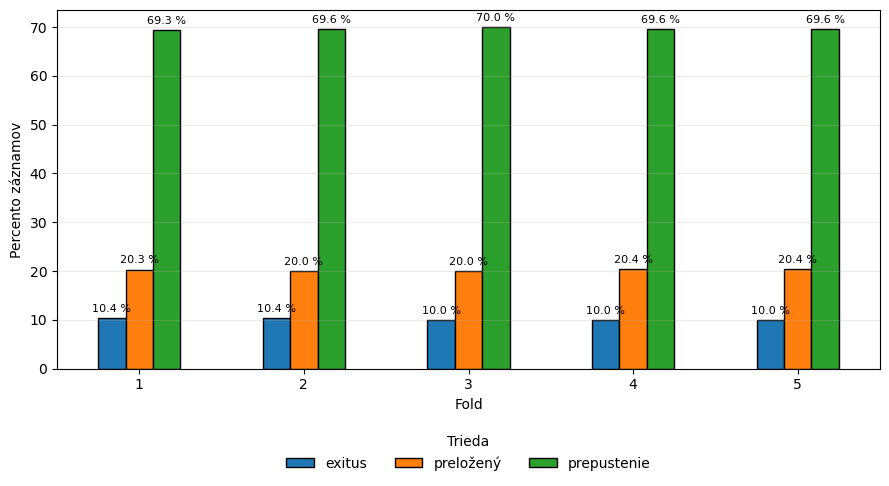

In [36]:
fold_distribution_plot = fold_distribution_df.pivot_table(
    index="fold",
    columns="trieda",
    values="percento"
)

ax = fold_distribution_plot.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

#plt.title("Percentuálne zastúpenie tried target_3 vo validačných foldoch")
plt.xlabel("Fold")
plt.ylabel("Percento záznamov")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)

# číselné hodnoty nad stĺpcami
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f} %" for v in container.datavalues],
        fontsize=8,
        padding=3
    )

# legenda pod grafom
ax.legend(
    title="Trieda",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(fold_distribution_plot.columns),
    frameon=False
)

plt.tight_layout()
plt.show()

In [37]:
#  Experiment 1: SIMPLE imputácia
#  numerické premenné = median, kategorické premenné = most_frequent

results_w4_boosting_simple_df = run_boosting_experiment("simple_median")
results_w4_tree_simple_df = run_tree_experiment("simple_median")

results_w4_simple_df = pd.concat(
    [results_w4_boosting_simple_df, results_w4_tree_simple_df],
    ignore_index=True
)

print("Výsledky simple_median:", results_w4_simple_df.shape)
results_w4_simple_df.head()



################################################################################
BOOSTING MODELY | imputácia: simple_median
################################################################################

Model: CatBoost
4. vlna | CatBoost | base_plus_ref_status_feature_sets | baseline_first_only | imputácia=simple_median (49 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | baseline_mixed | imputácia=simple_median (237 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | first_plus_indexes | imputácia=simple_median (85 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | mixed_plus_indexes | imputácia=simple_median (273 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | first_plus_extracted | imputácia=simple_median (84 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | mixed_plus_extracted | imputácia=simple_median (272 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | first_al

c:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | baseline_mixed | imputácia=simple_median (237 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | first_plus_indexes | imputácia=simple_median (85 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | mixed_plus_indexes | imputácia=simple_median (273 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | first_plus_extracted | imputácia=simple_median (84 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | mixed_plus_extracted | imputácia=simple_median (272 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | first_all_features | imputácia=simple_median (117 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | mixed_all_features | imputácia=simple_median (305 premenných)
4. vlna | HistGradientBoosting | base_plus_ref_status_feature_sets | ref_allowed_firs

,feature_set,model,target,imputation_strategy,cv_type,fold,n_splits,n_features,n_rows,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_weighted,dataset_subset,experiment_group
0,baseline_first_only,CatBoost,target_3,simple_median,grouped,1,5,49,1251,0.696356,0.540813,0.576584,0.540813,0.552821,0.688892,0.761604,wave_4,base_plus_ref_status_feature_sets
1,baseline_first_only,CatBoost,target_3,simple_median,grouped,2,5,49,1251,0.676000,0.524878,0.510328,0.524878,0.516135,0.679754,0.751948,wave_4,base_plus_ref_status_feature_sets
2,baseline_first_only,CatBoost,target_3,simple_median,grouped,3,5,49,1251,0.701195,0.553299,0.548155,0.553299,0.550345,0.705611,0.772526,wave_4,base_plus_ref_status_feature_sets
3,baseline_first_only,CatBoost,target_3,simple_median,grouped,4,5,49,1251,0.661355,0.550273,0.502129,0.550273,0.516401,0.670225,0.743958,wave_4,base_plus_ref_status_feature_sets
4,baseline_first_only,CatBoost,target_3,simple_median,grouped,5,5,49,1251,0.706349,0.568155,0.570056,0.568155,0.568506,0.701786,0.785465,wave_4,base_plus_ref_status_feature_sets


In [38]:
#  Experiment 2: KNN imputácia

results_w4_boosting_knn_df = run_boosting_experiment("knn")
results_w4_tree_knn_df = run_tree_experiment("knn")

results_w4_knn_df = pd.concat(
    [results_w4_boosting_knn_df, results_w4_tree_knn_df],
    ignore_index=True
)

print("Výsledky KNN:", results_w4_knn_df.shape)
results_w4_knn_df.head()



################################################################################
BOOSTING MODELY | imputácia: knn
################################################################################

Model: CatBoost
4. vlna | CatBoost | base_plus_ref_status_feature_sets | baseline_first_only | imputácia=knn (49 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | baseline_mixed | imputácia=knn (237 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | first_plus_indexes | imputácia=knn (85 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | mixed_plus_indexes | imputácia=knn (273 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | first_plus_extracted | imputácia=knn (84 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | mixed_plus_extracted | imputácia=knn (272 premenných)
4. vlna | CatBoost | base_plus_ref_status_feature_sets | first_all_features | imputácia=knn (117 premenných)
4. vlna | CatBoost | base_

,feature_set,model,target,imputation_strategy,cv_type,fold,n_splits,n_features,n_rows,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_weighted,dataset_subset,experiment_group
0,baseline_first_only,CatBoost,target_3,knn,grouped,1,5,49,1251,0.635628,0.452100,0.457619,0.452100,0.454508,0.630394,0.747272,wave_4,base_plus_ref_status_feature_sets
1,baseline_first_only,CatBoost,target_3,knn,grouped,2,5,49,1251,0.648000,0.525236,0.502206,0.525236,0.511684,0.656172,0.747879,wave_4,base_plus_ref_status_feature_sets
2,baseline_first_only,CatBoost,target_3,knn,grouped,3,5,49,1251,0.689243,0.505873,0.501892,0.505873,0.502854,0.681718,0.749895,wave_4,base_plus_ref_status_feature_sets
3,baseline_first_only,CatBoost,target_3,knn,grouped,4,5,49,1251,0.637450,0.480014,0.453984,0.480014,0.463246,0.648921,0.741321,wave_4,base_plus_ref_status_feature_sets
4,baseline_first_only,CatBoost,target_3,knn,grouped,5,5,49,1251,0.678571,0.528441,0.528222,0.528441,0.528070,0.675789,0.752604,wave_4,base_plus_ref_status_feature_sets


In [39]:
#  Spojenie výsledkov zo samostatných imputačných behov
#  Použité stratégie: simple_median a knn

boosting_parts = []
for name in [
    "results_w4_boosting_simple_df",
    "results_w4_boosting_knn_df",
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
        boosting_parts.append(globals()[name])

if len(boosting_parts) > 0:
    results_w4_boosting_ref_df = pd.concat(boosting_parts, ignore_index=True)
else:
    results_w4_boosting_ref_df = pd.DataFrame()


tree_parts = []
for name in [
    "results_w4_tree_simple_df",
    "results_w4_tree_knn_df",
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
        tree_parts.append(globals()[name])

if len(tree_parts) > 0:
    results_w4_tree_ref_df = pd.concat(tree_parts, ignore_index=True)
else:
    results_w4_tree_ref_df = pd.DataFrame()


all_imputation_parts = []
for name in [
    "results_w4_simple_df",
    "results_w4_knn_df",
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
        all_imputation_parts.append(globals()[name])

if len(all_imputation_parts) == 0:
    raise ValueError("Nenašli sa žiadne výsledky z imputačných experimentov.")

results_w4_all_imputations_df = pd.concat(
    all_imputation_parts,
    ignore_index=True
)

print("Boosting výsledky:", results_w4_boosting_ref_df.shape)
print("Tree výsledky:", results_w4_tree_ref_df.shape)
print("Všetky imputačné výsledky:", results_w4_all_imputations_df.shape)

results_w4_all_imputations_df.head()


Boosting výsledky: (280, 18)
Tree výsledky: (280, 18)
Všetky imputačné výsledky: (560, 18)


,feature_set,model,target,imputation_strategy,cv_type,fold,n_splits,n_features,n_rows,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_weighted,dataset_subset,experiment_group
0,baseline_first_only,CatBoost,target_3,simple_median,grouped,1,5,49,1251,0.696356,0.540813,0.576584,0.540813,0.552821,0.688892,0.761604,wave_4,base_plus_ref_status_feature_sets
1,baseline_first_only,CatBoost,target_3,simple_median,grouped,2,5,49,1251,0.676000,0.524878,0.510328,0.524878,0.516135,0.679754,0.751948,wave_4,base_plus_ref_status_feature_sets
2,baseline_first_only,CatBoost,target_3,simple_median,grouped,3,5,49,1251,0.701195,0.553299,0.548155,0.553299,0.550345,0.705611,0.772526,wave_4,base_plus_ref_status_feature_sets
3,baseline_first_only,CatBoost,target_3,simple_median,grouped,4,5,49,1251,0.661355,0.550273,0.502129,0.550273,0.516401,0.670225,0.743958,wave_4,base_plus_ref_status_feature_sets
4,baseline_first_only,CatBoost,target_3,simple_median,grouped,5,5,49,1251,0.706349,0.568155,0.570056,0.568155,0.568506,0.701786,0.785465,wave_4,base_plus_ref_status_feature_sets


### 4.2 Agregácia výsledkov

Fold-level výsledky zo všetkých modelových skupín (boosting + tree)
a oboch imputačných stratégií sa zlúčia do jedného DataFrame `all_fold_results_final`.

Pre každú kombináciu modelu, príznakového setu a imputácie sa vypočíta
priemerná hodnota a štandardná odchýlka každej metriky cez všetky foldy.
Výsledkom je `summary_all_final` — 112 riadkov, jeden za každú konfiguráciu.

Celkovo: 4 modely × 14 príznakových setov × 2 imputácie = 112 konfigurácií,
každá na 5 foldoch → 560 fold-level záznamov.

In [40]:

# 1. Spojenie fold-level výsledkov zo všetkých modelových skupín

results_to_combine = []

if "results_w4_boosting_ref_df" in globals() and not results_w4_boosting_ref_df.empty:
    tmp = results_w4_boosting_ref_df.copy()
    tmp["model_family"] = "boosting"
    results_to_combine.append(tmp)

if "results_w4_tree_ref_df" in globals() and not results_w4_tree_ref_df.empty:
    tmp = results_w4_tree_ref_df.copy()
    tmp["model_family"] = "tree"
    results_to_combine.append(tmp)

if len(results_to_combine) == 0:
    raise ValueError("Nenašli sa žiadne výsledkové tabuľky na export.")

all_fold_results_final = pd.concat(
    results_to_combine,
    ignore_index=True
)

print("Fold-level výsledky podľa modelu:")
print(all_fold_results_final["model"].value_counts())
print("\nFold-level výsledky podľa imputácie:")
print(all_fold_results_final["imputation_strategy"].value_counts())
print(all_fold_results_final.shape)


Fold-level výsledky podľa modelu:
model
CatBoost                140
XGBoost                 140
HistGradientBoosting    140
RandomForest            140
Name: count, dtype: int64

Fold-level výsledky podľa imputácie:
imputation_strategy
simple_median    280
knn              280
Name: count, dtype: int64
(560, 19)


In [41]:
# 2. Označenie typu informácie: admission vs mixed

def classify_information_type(feature_set_name: str) -> str:
    name = feature_set_name.lower()

    if "mixed" in name:
        return "mixed"

    if (
        "first" in name
        or "baseline_first" in name
        or "ref_allowed_first" in name
    ):
        return "admission"

    return "unknown"


all_fold_results_final["information_type"] = (
    all_fold_results_final["feature_set"]
    .apply(classify_information_type)
)

print("Rozdelenie podľa information_type:")
print(all_fold_results_final["information_type"].value_counts(dropna=False))

Rozdelenie podľa information_type:
information_type
admission    280
mixed        280
Name: count, dtype: int64


In [42]:
# 3. Jednotný summary výpočet zo všetkých foldov


summary_all_final = (
    all_fold_results_final
    .groupby([
        "dataset_subset",
        "experiment_group",
        "information_type",
        "target",
        "model_family",
        "model",
        "imputation_strategy",
        "feature_set",
        "n_features"
    ])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),

        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),

        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),

        recall_macro_mean=("recall_macro", "mean"),
        recall_macro_std=("recall_macro", "std"),

        precision_macro_mean=("precision_macro", "mean"),
        precision_macro_std=("precision_macro", "std"),

        roc_auc_mean=("roc_auc_ovr_weighted", "mean"),
        roc_auc_std=("roc_auc_ovr_weighted", "std"),

        n_folds=("fold", "nunique"),
        n_rows=("n_rows", "max")
    )
    .reset_index()
)

# Zaokrúhlenie
metric_cols = [
    col for col in summary_all_final.columns
    if col.endswith("_mean") or col.endswith("_std")
]

summary_all_final[metric_cols] = summary_all_final[metric_cols].round(4)

# Zoradenie podľa hlavnej metriky
summary_all_final = summary_all_final.sort_values(
    "f1_macro_mean",
    ascending=False
)

summary_all_final.head(20)


# ------------------------------------------------------------
# 4. Rozdelenie na admission a mixed summary


summary_admission_final = (
    summary_all_final[
        summary_all_final["information_type"] == "admission"
    ]
    .sort_values("f1_macro_mean", ascending=False)
    .copy()
)

summary_mixed_final = (
    summary_all_final[
        summary_all_final["information_type"] == "mixed"
    ]
    .sort_values("f1_macro_mean", ascending=False)
    .copy()
)

print("Spoločný summary:", summary_all_final.shape)
print("Admission summary:", summary_admission_final.shape)
print("Mixed summary:", summary_mixed_final.shape)

Spoločný summary: (112, 25)
Admission summary: (56, 25)
Mixed summary: (56, 25)


In [43]:
print(results_w4_all_imputations_df.columns.tolist())
print(summary_all_final.columns.tolist())

['feature_set', 'model', 'target', 'imputation_strategy', 'cv_type', 'fold', 'n_splits', 'n_features', 'n_rows', 'accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted', 'roc_auc_ovr_weighted', 'dataset_subset', 'experiment_group']
['dataset_subset', 'experiment_group', 'information_type', 'target', 'model_family', 'model', 'imputation_strategy', 'feature_set', 'n_features', 'accuracy_mean', 'accuracy_std', 'balanced_accuracy_mean', 'balanced_accuracy_std', 'f1_macro_mean', 'f1_macro_std', 'f1_weighted_mean', 'f1_weighted_std', 'recall_macro_mean', 'recall_macro_std', 'precision_macro_mean', 'precision_macro_std', 'roc_auc_mean', 'roc_auc_std', 'n_folds', 'n_rows']


In [44]:
summary_short_cols = [
    "dataset_subset",
    "experiment_group",
    "information_type",
    "target",
    "model_family",
    "model",
    "imputation_strategy",
    "feature_set",
    "n_features",
    "f1_macro_mean",
    "f1_macro_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_weighted_mean",
    "recall_macro_mean",
    "precision_macro_mean",
    "roc_auc_mean",
    "n_folds",
    "n_rows"
]

summary_all_short = summary_all_final[summary_short_cols].copy()

summary_admission_short = summary_admission_final[summary_short_cols].copy()

summary_mixed_short = summary_mixed_final[summary_short_cols].copy()

# ------------------------------------------------------------
# Porovnanie imputácií naprieč všetkými modelmi a feature setmi

summary_imputation_overall = (
    summary_all_final
    .groupby("imputation_strategy")
    .agg(
        n_configs=("f1_macro_mean", "count"),
        mean_f1_macro=("f1_macro_mean", "mean"),
        max_f1_macro=("f1_macro_mean", "max"),
        mean_balanced_accuracy=("balanced_accuracy_mean", "mean"),
        max_balanced_accuracy=("balanced_accuracy_mean", "max"),
        mean_roc_auc=("roc_auc_mean", "mean")
    )
    .reset_index()
    .sort_values("mean_f1_macro", ascending=False)
)

summary_imputation_by_model = (
    summary_all_final
    .groupby(["model", "imputation_strategy"])
    .agg(
        n_configs=("f1_macro_mean", "count"),
        mean_f1_macro=("f1_macro_mean", "mean"),
        max_f1_macro=("f1_macro_mean", "max"),
        mean_balanced_accuracy=("balanced_accuracy_mean", "mean"),
        max_balanced_accuracy=("balanced_accuracy_mean", "max"),
        mean_roc_auc=("roc_auc_mean", "mean")
    )
    .reset_index()
    .sort_values(["model", "mean_f1_macro"], ascending=[True, False])
)

summary_best_per_imputation = (
    summary_all_final
    .sort_values(["f1_macro_mean", "balanced_accuracy_mean"], ascending=False)
    .groupby("imputation_strategy")
    .head(10)
    .reset_index(drop=True)
)

summary_imputation_pivot = (
    summary_all_final
    .pivot_table(
        index=["model", "feature_set", "information_type"],
        columns="imputation_strategy",
        values="f1_macro_mean",
        aggfunc="max"
    )
    .reset_index()
)

if {"simple_median", "knn"}.issubset(summary_imputation_pivot.columns):
    summary_imputation_pivot["delta_knn_minus_simple"] = (
        summary_imputation_pivot["knn"]
        - summary_imputation_pivot["simple_median"]
    )

for df_summary in [
    summary_imputation_overall,
    summary_imputation_by_model,
    summary_best_per_imputation,
    summary_imputation_pivot
]:
    numeric_cols = df_summary.select_dtypes(include=["number"]).columns
    df_summary[numeric_cols] = df_summary[numeric_cols].round(4)

print("Porovnanie imputácií - overall:")
display(summary_imputation_overall)

print("Porovnanie imputácií podľa modelu:")
display(summary_imputation_by_model)


Porovnanie imputácií - overall:


,imputation_strategy,n_configs,mean_f1_macro,max_f1_macro,mean_balanced_accuracy,max_balanced_accuracy,mean_roc_auc
1,simple_median,56,0.551,0.6944,0.5505,0.7094,0.7919
0,knn,56,0.541,0.6886,0.5400,0.7031,0.7881


Porovnanie imputácií podľa modelu:


,model,imputation_strategy,n_configs,mean_f1_macro,max_f1_macro,mean_balanced_accuracy,max_balanced_accuracy,mean_roc_auc
1,CatBoost,simple_median,14,0.5960,0.6944,0.6101,0.7094,0.8005
0,CatBoost,knn,14,0.5857,0.6886,0.5974,0.7031,0.7948
3,HistGradientBoosting,simple_median,14,0.5718,0.6666,0.5562,0.6468,0.7848
2,HistGradientBoosting,knn,14,0.5599,0.6516,0.5458,0.6341,0.7829
5,RandomForest,simple_median,14,0.4517,0.5403,0.4502,0.5201,0.7941
4,RandomForest,knn,14,0.4465,0.5296,0.4466,0.5109,0.7902
7,XGBoost,simple_median,14,0.5845,0.6842,0.5854,0.6811,0.7882
6,XGBoost,knn,14,0.5720,0.6637,0.5702,0.6614,0.7847


### 4.3 Export výsledkov experimentov

Kompletné fold-level výsledky aj agregovaný summary sa exportujú do
`Výsledky_wave4_target3.xlsx` s dvoma hárkami:
- `fold_results` — surové výsledky každého foldu pre každú konfiguráciu
- `summary` — priemerné metriky a štandardné odchýlky cez všetky foldy

Tento súbor slúži ako vstup pre sekciu 6 — umožňuje opakované spúšťanie
vizualizačných buniek bez nutnosti znovu trénovať modely.

In [ ]:
output_file = "Výsledky_wave4_target3.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    
    # 1. Hlavné hárky s kompletnými metrikami
    summary_all_final.to_excel(
        writer,
        sheet_name="spolocny",
        index=False
    )

    summary_admission_final.to_excel(
        writer,
        sheet_name="admission",
        index=False
    )

    summary_mixed_final.to_excel(
        writer,
        sheet_name="mixed",
        index=False
    )

    # 2. Skrátené prehľady
    summary_all_short.to_excel(
        writer,
        sheet_name="spolocny_short",
        index=False
    )

    summary_admission_short.to_excel(
        writer,
        sheet_name="admission_short",
        index=False
    )

    summary_mixed_short.to_excel(
        writer,
        sheet_name="mixed_short",
        index=False
    )

    # 3. Porovnanie imputácií
    summary_imputation_overall.to_excel(
        writer,
        sheet_name="imputation_overall",
        index=False
    )

    summary_imputation_by_model.to_excel(
        writer,
        sheet_name="imputation_by_model",
        index=False
    )

    summary_best_per_imputation.to_excel(
        writer,
        sheet_name="best_per_imputation",
        index=False
    )

    summary_imputation_pivot.to_excel(
        writer,
        sheet_name="imputation_pivot",
        index=False
    )

    # 4. Výsledky po jednotlivých foldoch
    all_fold_results_final.to_excel(
        writer,
        sheet_name="fold_results",
        index=False
    )

print(f"Exportované: {output_file}")


Exportované: Výsledky_wave4_target3.xlsx


## 5. Cross validacia pre najlepší model

V tejto časti sa pre vybranú najlepšiu kombináciu modelu a feature setu znovu spustí 5-fold cross-validation iba pre túto jednu kombináciu.  
Cieľom je získať out-of-fold (OOF) predikcie, z ktorých sa následne vytvorí absolútna a normalizovaná confusion matrix.

Na rozdiel od predchádzajúcej modelovacej časti sa tu nespúšťajú všetky modely a všetky feature sety, ale iba jedna vybraná konfigurácia.

In [46]:
# ============================================================
#  Výber najlepšieho modelu pre confusion matrix
# ============================================================

best_row = (
    summary_all_final
    .sort_values(
        ["f1_macro_mean", "balanced_accuracy_mean"],
        ascending=False
    )
    .iloc[0]
)

BEST_MODEL = best_row["model"]
BEST_FEATURE_SET = best_row["feature_set"]
BEST_IMPUTATION_STRATEGY = best_row.get("imputation_strategy", "simple_median")

print("Vybraný model pre confusion matrix:")
print(f"Model: {BEST_MODEL}")
print(f"Feature set: {BEST_FEATURE_SET}")
print(f"Imputácia: {BEST_IMPUTATION_STRATEGY}")
print(f"F1 macro: {best_row['f1_macro_mean']:.3f}")
print(f"Balanced accuracy: {best_row['balanced_accuracy_mean']:.3f}")
print(f"ROC AUC: {best_row['roc_auc_mean']:.3f}")


Vybraný model pre confusion matrix:
Model: CatBoost
Feature set: mixed_all_plus_ref_allowed
Imputácia: simple_median
F1 macro: 0.694
Balanced accuracy: 0.709
ROC AUC: 0.846


In [47]:
#  Spoločný slovník feature setov pre confusion matrix


ALL_FEATURE_SETS_FOR_CM = {
    **FEATURE_SETS_CLEAN,
    **FEATURE_SETS_REF_STATUS
}

# odstránenie stĺpcov, ktoré sú v 4. vlne celé prázdne
ALL_FEATURE_SETS_FOR_CM_W4 = {
    name: [
        col for col in cols
        if col in df_main.columns and not df_main[col].isna().all()
    ]
    for name, cols in ALL_FEATURE_SETS_FOR_CM.items()
}

feature_cols_best = ALL_FEATURE_SETS_FOR_CM_W4[BEST_FEATURE_SET]

print(f"Počet premenných pre confusion matrix: {len(feature_cols_best)}")

# ============================================================
#  Výber pipeline podľa názvu modelu


def build_pipeline_for_confusion_matrix(
    model_name: str,
    X: pd.DataFrame,
    imputation_strategy: str = "simple_median"
):
    if model_name == "CatBoost":
        return build_boosting_pipeline(X, model_type="catboost", imputation_strategy=imputation_strategy)

    if model_name == "XGBoost":
        return build_boosting_pipeline(X, model_type="xgboost", imputation_strategy=imputation_strategy)

    if model_name == "HistGradientBoosting":
        return build_tree_pipeline(X, model_type="hgb", imputation_strategy=imputation_strategy)

    if model_name == "RandomForest":
        return build_tree_pipeline(X, model_type="rf", imputation_strategy=imputation_strategy)

    raise ValueError(f"Neznámy model: {model_name}")


Počet premenných pre confusion matrix: 465


In [48]:
#  Out-of-fold predikcie pre confusion matrix

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight

target_col = TARGET_COL_MODELING

data_cm = df_main[feature_cols_best + [target_col]].dropna(
    subset=[target_col]
).copy()

X_cm = data_cm[feature_cols_best].copy()
y_raw_cm = data_cm[target_col].copy()

label_encoder_cm = LabelEncoder()
y_cm = label_encoder_cm.fit_transform(y_raw_cm)

class_names_cm = label_encoder_cm.classes_

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_cm, y_cm), start=1):
    print(f"Fold {fold}/{N_SPLITS}")

    X_train = X_cm.iloc[train_idx]
    X_test = X_cm.iloc[test_idx]

    y_train = y_cm[train_idx]
    y_test = y_cm[test_idx]

    pipeline = build_pipeline_for_confusion_matrix(
        BEST_MODEL,
        X_train,
        imputation_strategy=BEST_IMPUTATION_STRATEGY
    )

    # CatBoost/XGBoost používajú sample_weight
    if BEST_MODEL in ["CatBoost", "XGBoost"]:
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train
        )

        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weight
        )

    else:
        pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)


Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


,pred_exitus,pred_preložený,pred_prepustenie
true_exitus,92,22,13
true_preložený,30,121,102
true_prepustenie,24,92,755


,pred_exitus,pred_preložený,pred_prepustenie
true_exitus,0.724,0.173,0.102
true_preložený,0.119,0.478,0.403
true_prepustenie,0.028,0.106,0.867


Classification report:
              precision    recall  f1-score   support

      exitus      0.630     0.724     0.674       127
   preložený      0.515     0.478     0.496       253
 prepustenie      0.868     0.867     0.867       871

    accuracy                          0.774      1251
   macro avg      0.671     0.690     0.679      1251
weighted avg      0.772     0.774     0.773      1251



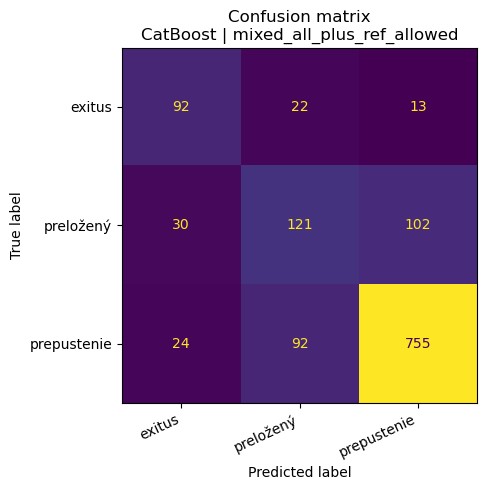

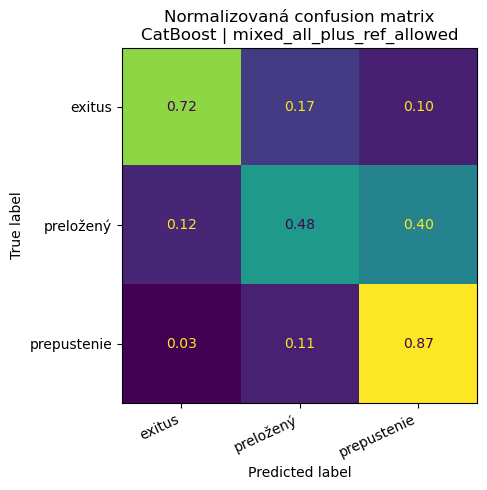

In [49]:
#  Confusion matrix – absolútna a normalizovaná

cm_abs = confusion_matrix(
    y_true_all,
    y_pred_all
)

cm_norm = confusion_matrix(
    y_true_all,
    y_pred_all,
    normalize="true"
)

cm_abs_df = pd.DataFrame(
    cm_abs,
    index=[f"true_{name}" for name in class_names_cm],
    columns=[f"pred_{name}" for name in class_names_cm]
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"true_{name}" for name in class_names_cm],
    columns=[f"pred_{name}" for name in class_names_cm]
)

display(cm_abs_df)
display(cm_norm_df.round(3))

print("Classification report:")
print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=class_names_cm,
        digits=3
    )
)

# ============================================================
#  Vizualizácia confusion matrix


from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_abs,
    display_labels=class_names_cm
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    f"Confusion matrix\n{BEST_MODEL} | {BEST_FEATURE_SET}"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names_cm
)

disp.plot(
    ax=ax,
    values_format=".2f",
    colorbar=False
)

ax.set_title(
    f"Normalizovaná confusion matrix\n{BEST_MODEL} | {BEST_FEATURE_SET}"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 5.1 Vizualizácia výsledkov modelovania

Prehľadová vizualizácia výsledkov všetkých 112 konfigurácií:

- **Top 10 konfigurácií** — horizontálny barplot zoradený podľa `F1 macro`,
  s vyznačením štandardnej odchýlky cez foldy
- **Heatmapa** — príznakové sety vs modely, farebne kódovaná priemerná `F1 macro`,
  umožňuje rýchlo identifikovať ktoré kombinácie fungujú najlepšie
- **Admission vs Mixed** — porovnanie dvoch režimov príznakov pre každý model,
  overuje či informácia o priebehu hospitalizácie zlepšuje predikciu oproti
  vstupným hodnotám

Najlepší výsledok: `CatBoost` + `mixed_all_plus_ref_allowed` + `simple_median`
→ F1 macro `0.694`, Balanced accuracy `0.709`, ROC AUC `0.846`.

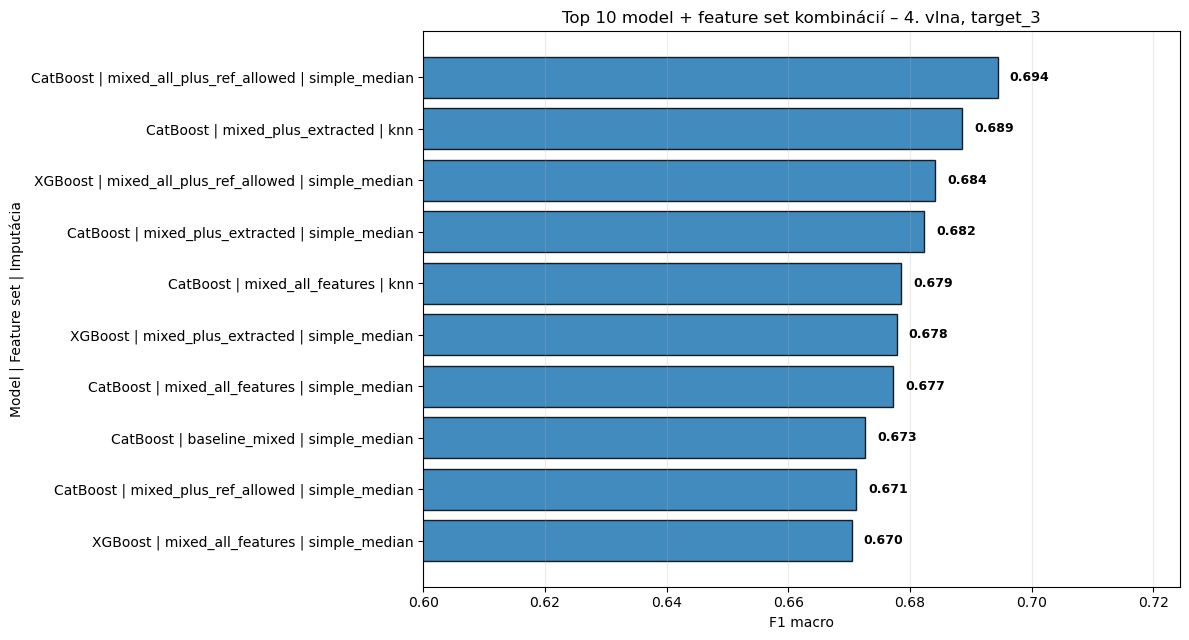

In [50]:
top_n_results = 10

plot_df = (
    summary_all_final
    .sort_values("f1_macro_mean", ascending=False)
    .head(top_n_results)
    .copy()
)

plot_df["label"] = (
    plot_df["model"]
    + " | "
    + plot_df["feature_set"]
    + " | "
    + plot_df["imputation_strategy"]
)

# otočíme poradie, aby najlepší bol hore
plot_df = plot_df.iloc[::-1]

plt.figure(figsize=(12, 6.5))

bars = plt.barh(
    plot_df["label"],
    plot_df["f1_macro_mean"],
    edgecolor="black",
    alpha=0.85
)

for bar, value in zip(bars, plot_df["f1_macro_mean"]):
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Top 10 model + feature set kombinácií – 4. vlna, target_3")
plt.xlabel("F1 macro")
plt.ylabel("Model | Feature set | Imputácia")
plt.xlim(0.60, plot_df["f1_macro_mean"].max() + 0.03)
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

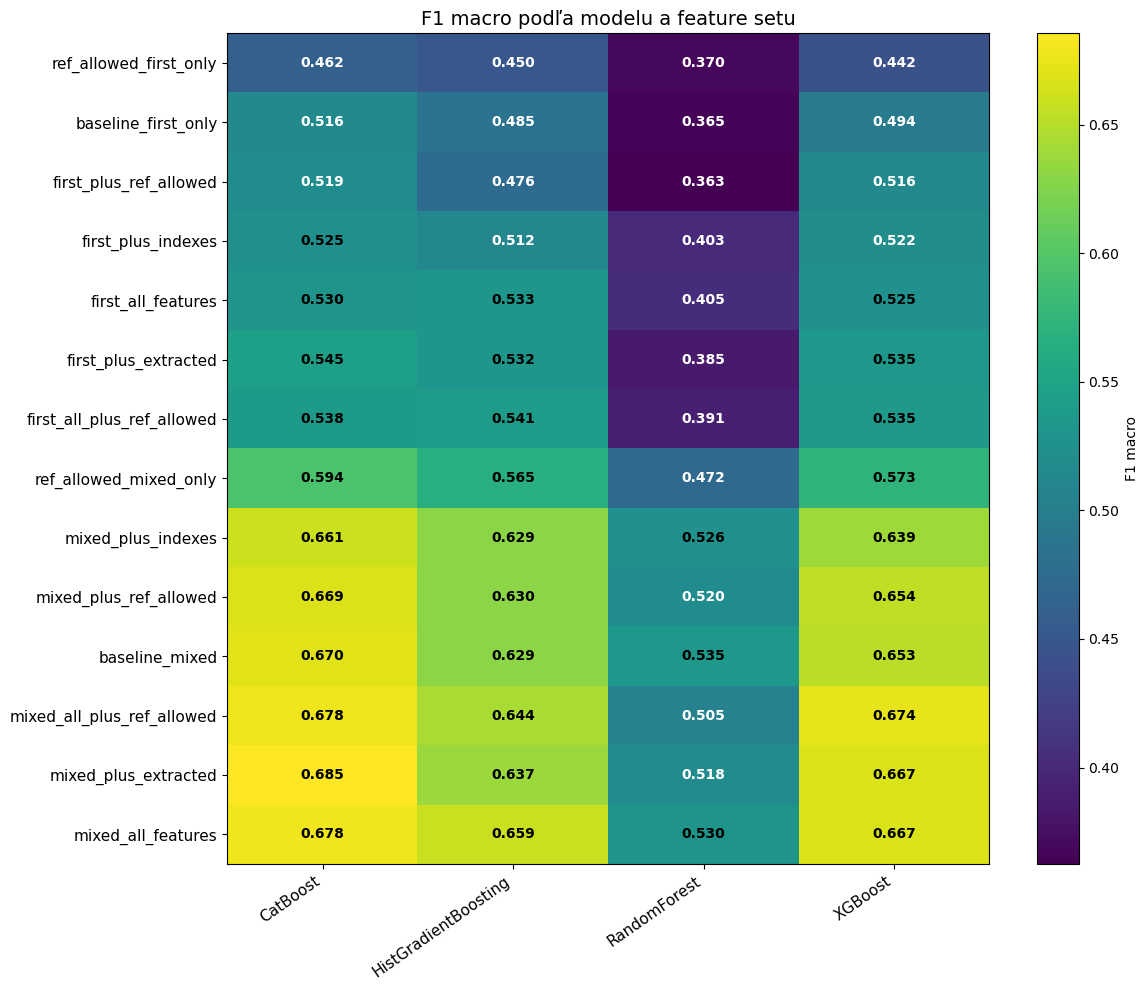

In [51]:
heatmap_df = summary_all_final.pivot_table(
    index="feature_set",
    columns="model",
    values="f1_macro_mean",
    aggfunc="mean"
)

# voliteľne: zoradenie podľa priemeru cez modely
heatmap_df = heatmap_df.loc[
    heatmap_df.mean(axis=1).sort_values().index
]

plt.figure(figsize=(12, 10))

im = plt.imshow(
    heatmap_df,
    aspect="auto"
)

plt.colorbar(im, label="F1 macro")

plt.xticks(
    range(len(heatmap_df.columns)),
    heatmap_df.columns,
    rotation=35,
    ha="right",
    fontsize=11
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index,
    fontsize=11
)

# lepší kontrast textu
vmin = np.nanmin(heatmap_df.values)
vmax = np.nanmax(heatmap_df.values)
threshold = (vmin + vmax) / 2

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]

        if pd.notna(value):
            text_color = "white" if value < threshold else "black"

            plt.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=10,
                fontweight="bold"
            )

plt.title("F1 macro podľa modelu a feature setu", fontsize=14)
plt.tight_layout()
plt.show()

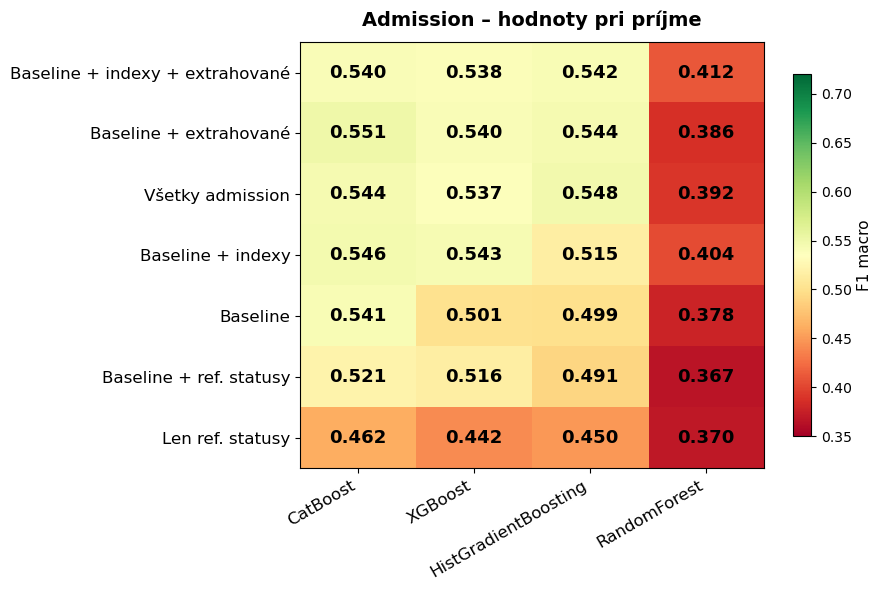

Uložené: heatmapa_admission.png


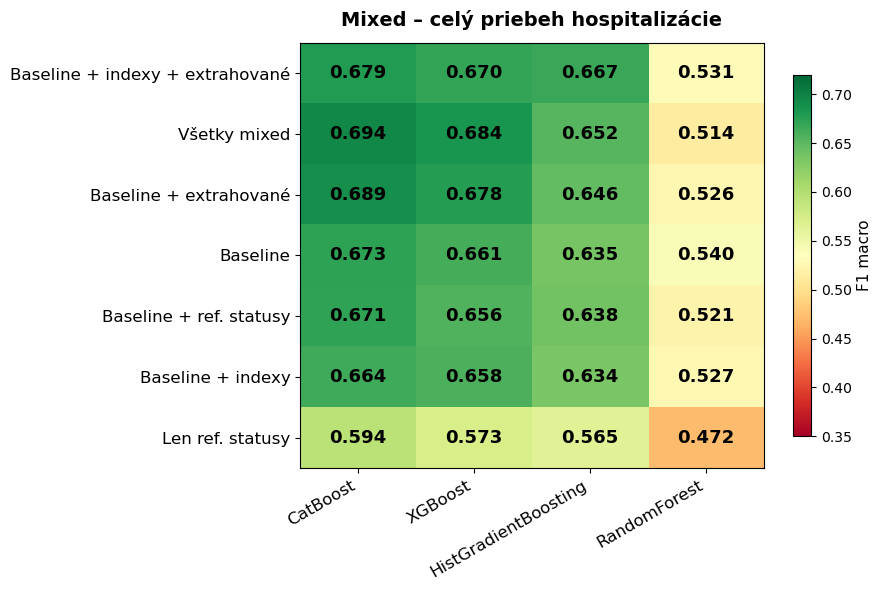

Uložené: heatmapa_mixed.png


In [52]:

feature_set_labels = {
    "baseline_first_only":        "Baseline",
    "first_plus_indexes":         "Baseline + indexy",
    "first_plus_extracted":       "Baseline + extrahované",
    "first_all_features":         "Baseline + indexy + extrahované",
    "first_plus_ref_allowed":     "Baseline + ref. statusy",
    "first_all_plus_ref_allowed": "Všetky admission",
    "ref_allowed_first_only":     "Len ref. statusy",
    "baseline_mixed":             "Baseline",
    "mixed_plus_indexes":         "Baseline + indexy",
    "mixed_plus_extracted":       "Baseline + extrahované",
    "mixed_all_features":         "Baseline + indexy + extrahované",
    "mixed_plus_ref_allowed":     "Baseline + ref. statusy",
    "mixed_all_plus_ref_allowed": "Všetky mixed",
    "ref_allowed_mixed_only":     "Len ref. statusy",
}

model_order = ["CatBoost", "XGBoost", "HistGradientBoosting", "RandomForest"]
vmin, vmax = 0.35, 0.72

for info_type, title, fname in [
    ("admission", "Admission – hodnoty pri príjme",     "heatmapa_admission.png"),
    ("mixed",     "Mixed – celý priebeh hospitalizácie","heatmapa_mixed.png"),
]:
    subset = summary_all_final[summary_all_final["information_type"] == info_type]

    heatmap_df = (
        subset
        .groupby(["feature_set", "model"])["f1_macro_mean"]
        .max()
        .unstack()
        .reindex(columns=model_order)
    )
    heatmap_df = heatmap_df.loc[
        heatmap_df.mean(axis=1).sort_values(ascending=False).index
    ]
    heatmap_df.index = [feature_set_labels.get(fs, fs) for fs in heatmap_df.index]

    fig, ax = plt.subplots(figsize=(9, 6))

    im = ax.imshow(
        heatmap_df.values,
        aspect="auto",
        cmap="RdYlGn",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right", fontsize=12)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    threshold = (vmin + vmax) / 2
    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            val = heatmap_df.values[i, j]
            if not np.isnan(val):
                color = "black" 
                ax.text(
                    j, i, f"{val:.3f}",
                    ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color
                )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("F1 macro", fontsize=11)

    plt.tight_layout()
    #plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Uložené: {fname}")

C:\Users\DELL\AppData\Local\Temp\ipykernel_46168\1346124835.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


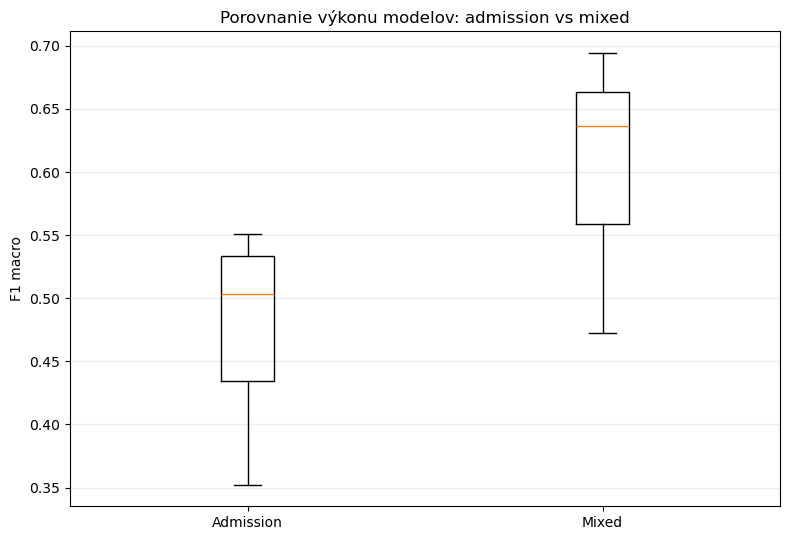

Admission F1 macro:
count    56.000
mean      0.479
std       0.063
min       0.352
25%       0.434
50%       0.503
75%       0.534
max       0.551
Name: f1_macro_mean, dtype: float64

Mixed F1 macro:
count    56.000
mean      0.613
std       0.065
min       0.472
25%       0.559
50%       0.637
75%       0.664
max       0.694
Name: f1_macro_mean, dtype: float64


In [53]:
#  Porovnanie admission a mixed modelov

admission_values = summary_all_final[
    summary_all_final["information_type"] == "admission"
]["f1_macro_mean"]

mixed_values = summary_all_final[
    summary_all_final["information_type"] == "mixed"
]["f1_macro_mean"]

plt.figure(figsize=(8, 5.5))

plt.boxplot(
    [admission_values, mixed_values],
    labels=["Admission", "Mixed"]
)

plt.title("Porovnanie výkonu modelov: admission vs mixed")
plt.ylabel("F1 macro")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("Admission F1 macro:")
print(admission_values.describe().round(3))

print("\nMixed F1 macro:")
print(mixed_values.describe().round(3))

## 6. Detailná evaluácia vybraných modelov pomocou confusion matrix

V tejto časti sa pre vybrané reprezentatívne modelové konfigurácie vytvára confusion matrix.  
Cieľom je overiť, ako modely rozlišujú jednotlivé triedy cieľovej premennej `target_3`.

Keďže predchádzajúce výsledky obsahujú iba agregované metriky z krížovej validácie, pre confusion matrix sa vybrané modely znovu spustia cez rovnaký cross-validation protokol.  
Nejde však o opakovanie celého modelovania, ale iba o vyhodnotenie niekoľkých vybraných konfigurácií.

In [54]:
#  Výber modelov pre confusion matrix


def select_best_config(summary_df, condition=None, label="best"):
    df = summary_df.copy()

    if condition is not None:
        df = df[condition(df)].copy()

    if df.empty:
        return None

    best_row = (
        df
        .sort_values(
            ["f1_macro_mean", "balanced_accuracy_mean"],
            ascending=False
        )
        .iloc[0]
    )

    return {
        "selection_label": label,
        "model": best_row["model"],
        "feature_set": best_row["feature_set"],
        "imputation_strategy": best_row.get("imputation_strategy", "simple_median"),
        "information_type": best_row["information_type"],
        "f1_macro_mean": best_row["f1_macro_mean"],
        "balanced_accuracy_mean": best_row["balanced_accuracy_mean"],
        "roc_auc_mean": best_row["roc_auc_mean"]
    }


selected_cm_configs = []

# Najlepší celkový model
selected_cm_configs.append(
    select_best_config(
        summary_all_final,
        label="best_overall"
    )
)

# Najlepší admission model
selected_cm_configs.append(
    select_best_config(
        summary_all_final,
        condition=lambda df: df["information_type"] == "admission",
        label="best_admission"
    )
)

# Najlepší mixed model
selected_cm_configs.append(
    select_best_config(
        summary_all_final,
        condition=lambda df: df["information_type"] == "mixed",
        label="best_mixed"
    )
)

# Najlepší ref/allowed model
selected_cm_configs.append(
    select_best_config(
        summary_all_final,
        condition=lambda df: df["feature_set"].str.contains("ref_allowed", case=False, na=False),
        label="best_ref_allowed"
    )
)

# Odstránenie None a duplicitných konfigurácií
selected_cm_configs_clean = []
seen = set()

for cfg in selected_cm_configs:
    if cfg is None:
        continue

    key = (cfg["model"], cfg["feature_set"], cfg["imputation_strategy"])

    if key not in seen:
        selected_cm_configs_clean.append(cfg)
        seen.add(key)

selected_cm_configs_df = pd.DataFrame(selected_cm_configs_clean)

selected_cm_configs_df


,selection_label,model,feature_set,imputation_strategy,information_type,f1_macro_mean,balanced_accuracy_mean,roc_auc_mean
0,best_overall,CatBoost,mixed_all_plus_ref_allowed,simple_median,mixed,0.6944,0.7094,0.846
1,best_admission,CatBoost,first_plus_extracted,simple_median,admission,0.5506,0.5569,0.794


In [55]:
#  Príprava feature setov pre confusion matrix

ALL_FEATURE_SETS_FOR_CM = {
    **FEATURE_SETS_CLEAN,
    **FEATURE_SETS_REF_STATUS
}

ALL_FEATURE_SETS_FOR_CM_W4 = {
    name: [
        col for col in cols
        if col in df_main.columns and not df_main[col].isna().all()
    ]
    for name, cols in ALL_FEATURE_SETS_FOR_CM.items()
}

print("Dostupné feature sety pre confusion matrix:")
for name, cols in ALL_FEATURE_SETS_FOR_CM_W4.items():
    print(f"{name}: {len(cols)} premenných")

Dostupné feature sety pre confusion matrix:
baseline_first_only: 49 premenných
baseline_mixed: 237 premenných
first_plus_indexes: 85 premenných
mixed_plus_indexes: 273 premenných
first_plus_extracted: 84 premenných
mixed_plus_extracted: 272 premenných
first_all_features: 117 premenných
mixed_all_features: 305 premenných
ref_allowed_first_only: 82 premenných
ref_allowed_mixed_only: 162 premenných
first_plus_ref_allowed: 129 premenných
mixed_plus_ref_allowed: 397 premenných
first_all_plus_ref_allowed: 197 premenných
mixed_all_plus_ref_allowed: 465 premenných


In [56]:
#  Výber pipeline podľa modelu

def build_pipeline_for_cm(
    model_name: str,
    X: pd.DataFrame,
    imputation_strategy: str = "simple_median"
):
    if model_name == "CatBoost":
        return build_boosting_pipeline(X, model_type="catboost", imputation_strategy=imputation_strategy)

    if model_name == "XGBoost":
        return build_boosting_pipeline(X, model_type="xgboost", imputation_strategy=imputation_strategy)

    if model_name == "HistGradientBoosting":
        return build_tree_pipeline(X, model_type="hgb", imputation_strategy=imputation_strategy)

    if model_name == "RandomForest":
        return build_tree_pipeline(X, model_type="rf", imputation_strategy=imputation_strategy)

    raise ValueError(f"Neznámy model: {model_name}")

# ============================================================
#  OOF predikcie a confusion matrix


def evaluate_confusion_matrix_cv(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    model_name: str,
    imputation_strategy: str = "simple_median",
    n_splits: int = N_SPLITS,
    random_state: int = RANDOM_STATE
):
    data = df[feature_cols + [target_col]].dropna(
        subset=[target_col]
    ).copy()

    X = data[feature_cols].copy()
    y_raw = data[target_col].copy()

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)

    class_names = label_encoder.classes_

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        print(f"{model_name} | {imputation_strategy} | Fold {fold}/{n_splits}")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        pipeline = build_pipeline_for_cm(
            model_name,
            X_train,
            imputation_strategy=imputation_strategy
        )

        if model_name in ["CatBoost", "XGBoost"]:
            sample_weight = compute_sample_weight(
                class_weight="balanced",
                y=y_train
            )

            pipeline.fit(
                X_train,
                y_train,
                model__sample_weight=sample_weight
            )
        else:
            pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    cm_abs = confusion_matrix(
        y_true_all,
        y_pred_all
    )

    cm_norm = confusion_matrix(
        y_true_all,
        y_pred_all,
        normalize="true"
    )

    report_dict = classification_report(
        y_true_all,
        y_pred_all,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).T

    return {
        "cm_abs": cm_abs,
        "cm_norm": cm_norm,
        "report_df": report_df,
        "class_names": class_names,
        "y_true": y_true_all,
        "y_pred": y_pred_all
    }


In [57]:
#  Confusion matrix pre vybrané konfigurácie

cm_results = {}

for _, cfg in selected_cm_configs_df.iterrows():
    label = cfg["selection_label"]
    model_name = cfg["model"]
    feature_set_name = cfg["feature_set"]
    imputation_strategy = cfg.get("imputation_strategy", "simple_median")

    print("\n" + "=" * 80)
    print(f"{label}: {model_name} | {feature_set_name} | imputácia={imputation_strategy}")
    print("=" * 80)

    feature_cols = ALL_FEATURE_SETS_FOR_CM_W4[feature_set_name]

    result = evaluate_confusion_matrix_cv(
        df=df_main,
        feature_cols=feature_cols,
        target_col=TARGET_COL_MODELING,
        model_name=model_name,
        imputation_strategy=imputation_strategy
    )

    cm_results[label] = {
        "config": cfg.to_dict(),
        **result
    }



best_overall: CatBoost | mixed_all_plus_ref_allowed | imputácia=simple_median
CatBoost | simple_median | Fold 1/5
CatBoost | simple_median | Fold 2/5
CatBoost | simple_median | Fold 3/5
CatBoost | simple_median | Fold 4/5
CatBoost | simple_median | Fold 5/5

best_admission: CatBoost | first_plus_extracted | imputácia=simple_median
CatBoost | simple_median | Fold 1/5
CatBoost | simple_median | Fold 2/5
CatBoost | simple_median | Fold 3/5
CatBoost | simple_median | Fold 4/5
CatBoost | simple_median | Fold 5/5


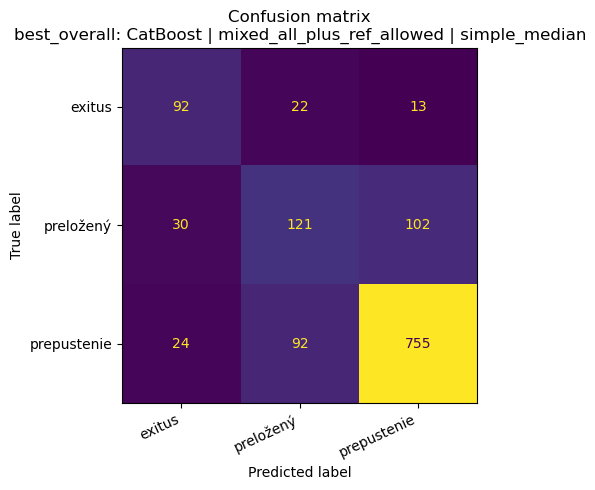

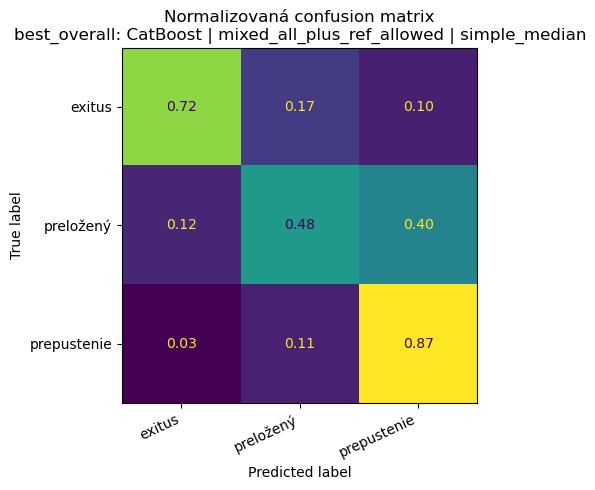

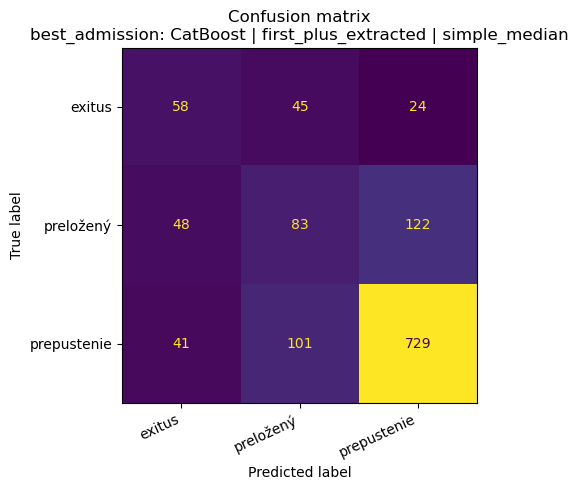

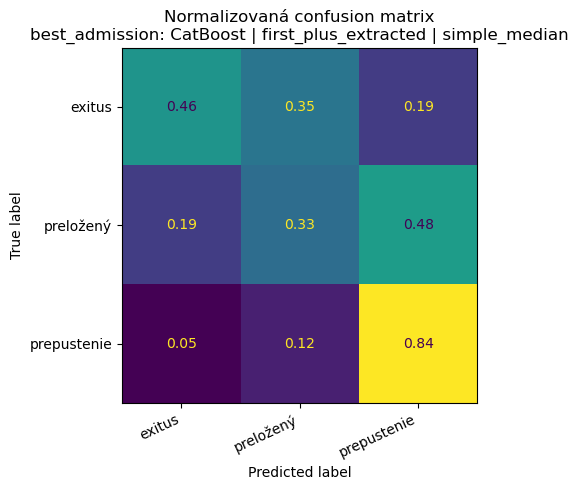

In [58]:
#  Vizualizácia confusion matrix


for label, result in cm_results.items():
    cfg = result["config"]
    model_name = cfg["model"]
    feature_set_name = cfg["feature_set"]
    imputation_strategy = cfg.get("imputation_strategy", "simple_median")
    class_names = result["class_names"]

    # Absolútna CM
    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["cm_abs"],
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"Confusion matrix\n{label}: {model_name} | {feature_set_name} | {imputation_strategy}"
    )

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

    # Normalizovaná CM
    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["cm_norm"],
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        values_format=".2f",
        colorbar=False
    )

    ax.set_title(
        f"Normalizovaná confusion matrix\n{label}: {model_name} | {feature_set_name} | {imputation_strategy}"
    )

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

In [59]:
#  Classification report pre vybrané modely

classification_reports = []

for label, result in cm_results.items():
    report_df = result["report_df"].copy()

    cfg = result["config"]

    report_df["selection_label"] = label
    report_df["model"] = cfg["model"]
    report_df["feature_set"] = cfg["feature_set"]

    classification_reports.append(report_df.reset_index().rename(columns={"index": "class"}))

classification_reports_df = pd.concat(
    classification_reports,
    ignore_index=True
)

classification_reports_df

,class,precision,recall,f1-score,support,selection_label,model,feature_set
0,exitus,0.630137,0.724409,0.673993,127.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed
1,preložený,0.514894,0.478261,0.495902,253.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed
2,prepustenie,0.867816,0.866820,0.867318,871.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed
3,accuracy,0.773781,0.773781,0.773781,0.773781,best_overall,CatBoost,mixed_all_plus_ref_allowed
4,macro avg,0.670949,0.689830,0.679071,1251.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed
5,weighted avg,0.772313,0.773781,0.772577,1251.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed
6,exitus,0.394558,0.456693,0.423358,127.000000,best_admission,CatBoost,first_plus_extracted
7,preložený,0.362445,0.328063,0.344398,253.000000,best_admission,CatBoost,first_plus_extracted
8,prepustenie,0.833143,0.836969,0.835052,871.000000,best_admission,CatBoost,first_plus_extracted
9,accuracy,0.695444,0.695444,0.695444,0.695444,best_admission,CatBoost,first_plus_extracted


In [60]:
#  Export classification reportov do Excelu


OUTPUT_EXCEL = "Výsledky_wave4_target3_class_report.xlsx"

classification_reports = []

for label, result in cm_results.items():
    report_df = result["report_df"].copy()
    cfg = result["config"]

    # Pridaj accuracy ako samostatný riadok ak tam nie je
    if "accuracy" not in report_df.index:
        acc = result.get("accuracy", None)
        if acc is not None:
            report_df.loc["accuracy"] = {
                "precision": acc,
                "recall":    acc,
                "f1-score":  acc,
                "support":   report_df["support"].dropna().sum()
            }

    report_df["selection_label"]   = label
    report_df["model"]             = cfg.get("model")
    report_df["feature_set"]       = cfg.get("feature_set")
    report_df["imputation_strategy"] = cfg.get("imputation_strategy", None)

    classification_reports.append(
        report_df.reset_index().rename(columns={"index": "class"})
    )

classification_reports_df = pd.concat(
    classification_reports,
    ignore_index=True
)

# bezpečný export do existujúceho Excelu
if os.path.exists(OUTPUT_EXCEL):
    with pd.ExcelWriter(
        OUTPUT_EXCEL,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        classification_reports_df.to_excel(
            writer,
            sheet_name="classification_reports",
            index=False
        )
else:
    with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
        classification_reports_df.to_excel(
            writer,
            sheet_name="classification_reports",
            index=False
        )

print(f"Classification reporty exportované do: {OUTPUT_EXCEL}")
print(classification_reports_df.shape)

classification_reports_df.head()

Classification reporty exportované do: Výsledky_wave4_target3_class_report.xlsx
(12, 9)


,class,precision,recall,f1-score,support,selection_label,model,feature_set,imputation_strategy
0,exitus,0.630137,0.724409,0.673993,127.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed,simple_median
1,preložený,0.514894,0.478261,0.495902,253.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed,simple_median
2,prepustenie,0.867816,0.866820,0.867318,871.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed,simple_median
3,accuracy,0.773781,0.773781,0.773781,0.773781,best_overall,CatBoost,mixed_all_plus_ref_allowed,simple_median
4,macro avg,0.670949,0.689830,0.679071,1251.000000,best_overall,CatBoost,mixed_all_plus_ref_allowed,simple_median


## 7. Validácia výsledkov

Štatistická validácia top 10 konfigurácií overuje či sú dosiahnuté výsledky
stabilné a reprodukovateľné:

- **Stabilita foldov** — boxplot rozptylu `F1 macro` cez 5 foldov pre každého
  top kandidáta, odhaľuje konfigurácie s vysokou variabilitou
- **Wilcoxon test** — neparametrický párový test porovnáva `simple_median`
  vs `knn` imputáciu na fold-level výsledkoch, overuje či je rozdiel štatisticky významný
- **95 % intervaly spoľahlivosti** — vypočítané z fold-level výsledkov
  pre každého top kandidáta
- **Súhrnný report** — najlepší model, feature set, imputácia a dosiahnuté metriky

Najlepší model: `CatBoost` + `mixed_all_plus_ref_allowed` + `simple_median`
→ F1 macro `0.694 ± std`, Balanced accuracy `0.709`, ROC AUC `0.846`.

In [61]:
#  Top kandidátne modelové konfigurácie


top_n_candidates = 10

candidate_cols = [
    "dataset_subset",
    "experiment_group",
    "information_type",
    "target",
    "model_family",
    "model",
    "imputation_strategy",
    "feature_set",
    "n_features",
    "f1_macro_mean",
    "f1_macro_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_weighted_mean",
    "recall_macro_mean",
    "precision_macro_mean",
    "roc_auc_mean",
    "roc_auc_std",
    "n_folds",
    "n_rows"
]

candidate_cols_existing = [
    col for col in candidate_cols
    if col in summary_all_final.columns
]

top_candidates_df = (
    summary_all_final[candidate_cols_existing]
    .sort_values(
        ["f1_macro_mean", "balanced_accuracy_mean", "roc_auc_mean"],
        ascending=[False, False, False]
    )
    .head(top_n_candidates)
    .reset_index(drop=True)
)

top_candidates_df

,dataset_subset,experiment_group,information_type,target,model_family,model,imputation_strategy,feature_set,n_features,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std,f1_weighted_mean,recall_macro_mean,precision_macro_mean,roc_auc_mean,roc_auc_std,n_folds,n_rows
0,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,simple_median,mixed_all_plus_ref_allowed,465,0.6944,0.0381,0.7094,0.0399,0.7790,0.7094,0.6893,0.8460,0.0135,5,1251
1,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,knn,mixed_plus_extracted,272,0.6886,0.0406,0.7031,0.0372,0.7763,0.7031,0.6833,0.8468,0.0123,5,1251
2,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,XGBoost,simple_median,mixed_all_plus_ref_allowed,465,0.6842,0.0396,0.6811,0.0292,0.7705,0.6811,0.6996,0.8351,0.0315,5,1251
3,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,simple_median,mixed_plus_extracted,272,0.6823,0.0184,0.7018,0.0320,0.7763,0.7018,0.6728,0.8453,0.0125,5,1251
4,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,knn,mixed_all_features,305,0.6786,0.0393,0.6847,0.0325,0.7700,0.6847,0.6776,0.8392,0.0087,5,1251
5,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,XGBoost,simple_median,mixed_plus_extracted,272,0.6778,0.0411,0.6770,0.0308,0.7691,0.6770,0.6926,0.8327,0.0272,5,1251
6,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,simple_median,mixed_all_features,305,0.6773,0.0232,0.6876,0.0237,0.7700,0.6876,0.6765,0.8441,0.0172,5,1251
7,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,simple_median,baseline_mixed,237,0.6726,0.0318,0.6894,0.0321,0.7660,0.6894,0.6655,0.8344,0.0134,5,1251
8,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,CatBoost,simple_median,mixed_plus_ref_allowed,397,0.6712,0.0609,0.6836,0.0524,0.7610,0.6836,0.6651,0.8349,0.0145,5,1251
9,wave_4,base_plus_ref_status_feature_sets,mixed,target_3,boosting,XGBoost,simple_median,mixed_all_features,305,0.6704,0.0433,0.6681,0.0378,0.7637,0.6681,0.6881,0.8364,0.0285,5,1251


In [62]:
#  Stabilita top kandidátov medzi foldmi

fold_stability_rows = []

for _, row in top_candidates_df.iterrows():

    mask = (
        (all_fold_results_final["model"] == row["model"]) &
        (all_fold_results_final["feature_set"] == row["feature_set"]) &
        (all_fold_results_final["imputation_strategy"] == row["imputation_strategy"])
    )

    if "target" in all_fold_results_final.columns and "target" in row.index:
        mask = mask & (all_fold_results_final["target"] == row["target"])

    if "dataset_subset" in all_fold_results_final.columns and "dataset_subset" in row.index:
        mask = mask & (all_fold_results_final["dataset_subset"] == row["dataset_subset"])

    if "experiment_group" in all_fold_results_final.columns and "experiment_group" in row.index:
        mask = mask & (all_fold_results_final["experiment_group"] == row["experiment_group"])

    fold_df = all_fold_results_final[mask].copy()

    if fold_df.empty:
        continue

    fold_stability_rows.append({
        "model": row["model"],
        "feature_set": row["feature_set"],
        "imputation_strategy": row["imputation_strategy"],
        "information_type": row.get("information_type", None),
        "n_features": row.get("n_features", np.nan),
        "n_folds": fold_df["fold"].nunique(),

        "f1_macro_mean": fold_df["f1_macro"].mean(),
        "f1_macro_std": fold_df["f1_macro"].std(),
        "f1_macro_min": fold_df["f1_macro"].min(),
        "f1_macro_max": fold_df["f1_macro"].max(),

        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(),

        "recall_macro_mean": fold_df["recall_macro"].mean(),
        "recall_macro_std": fold_df["recall_macro"].std(),

        "precision_macro_mean": fold_df["precision_macro"].mean(),
        "precision_macro_std": fold_df["precision_macro"].std(),

        "roc_auc_mean": fold_df["roc_auc_ovr_weighted"].mean(),
        "roc_auc_std": fold_df["roc_auc_ovr_weighted"].std()
    })

fold_stability_top_df = pd.DataFrame(fold_stability_rows)

numeric_cols = fold_stability_top_df.select_dtypes(include=["number"]).columns
fold_stability_top_df[numeric_cols] = fold_stability_top_df[numeric_cols].round(4)

fold_stability_top_df = fold_stability_top_df.sort_values(
    ["f1_macro_mean", "f1_macro_std"],
    ascending=[False, True]
).reset_index(drop=True)

fold_stability_top_df

,model,feature_set,imputation_strategy,information_type,n_features,n_folds,f1_macro_mean,f1_macro_std,f1_macro_min,f1_macro_max,balanced_accuracy_mean,balanced_accuracy_std,recall_macro_mean,recall_macro_std,precision_macro_mean,precision_macro_std,roc_auc_mean,roc_auc_std
0,CatBoost,mixed_all_plus_ref_allowed,simple_median,mixed,465,5,0.6944,0.0381,0.6629,0.7587,0.7094,0.0399,0.7094,0.0399,0.6893,0.0450,0.8460,0.0135
1,CatBoost,mixed_plus_extracted,knn,mixed,272,5,0.6886,0.0406,0.6580,0.7568,0.7031,0.0372,0.7031,0.0372,0.6833,0.0488,0.8468,0.0123
2,XGBoost,mixed_all_plus_ref_allowed,simple_median,mixed,465,5,0.6842,0.0396,0.6475,0.7471,0.6811,0.0292,0.6811,0.0292,0.6996,0.0493,0.8351,0.0315
3,CatBoost,mixed_plus_extracted,simple_median,mixed,272,5,0.6823,0.0184,0.6575,0.7069,0.7018,0.0320,0.7018,0.0320,0.6728,0.0225,0.8453,0.0125
4,CatBoost,mixed_all_features,knn,mixed,305,5,0.6786,0.0393,0.6580,0.7487,0.6847,0.0325,0.6847,0.0325,0.6776,0.0475,0.8392,0.0087
5,XGBoost,mixed_plus_extracted,simple_median,mixed,272,5,0.6778,0.0411,0.6284,0.7379,0.6770,0.0308,0.6770,0.0308,0.6926,0.0518,0.8327,0.0272
6,CatBoost,mixed_all_features,simple_median,mixed,305,5,0.6773,0.0232,0.6501,0.7123,0.6876,0.0237,0.6876,0.0237,0.6765,0.0389,0.8441,0.0172
7,CatBoost,baseline_mixed,simple_median,mixed,237,5,0.6726,0.0318,0.6321,0.7077,0.6894,0.0321,0.6894,0.0321,0.6655,0.0419,0.8344,0.0134
8,CatBoost,mixed_plus_ref_allowed,simple_median,mixed,397,5,0.6712,0.0609,0.6129,0.7690,0.6836,0.0524,0.6836,0.0524,0.6651,0.0724,0.8349,0.0145
9,XGBoost,mixed_all_features,simple_median,mixed,305,5,0.6704,0.0433,0.6309,0.7418,0.6681,0.0378,0.6681,0.0378,0.6881,0.0539,0.8364,0.0285


In [63]:
#  Fold-level výsledky pre top kandidátov


top_candidate_fold_rows = []

for rank, row in top_candidates_df.iterrows():

    mask = (
        (all_fold_results_final["model"] == row["model"]) &
        (all_fold_results_final["feature_set"] == row["feature_set"]) &
        (all_fold_results_final["imputation_strategy"] == row["imputation_strategy"])
    )

    if "target" in all_fold_results_final.columns and "target" in row.index:
        mask = mask & (all_fold_results_final["target"] == row["target"])

    fold_df = all_fold_results_final[mask].copy()

    if fold_df.empty:
        continue

    fold_df["candidate_rank"] = rank + 1
    fold_df["candidate_label"] = (
        fold_df["model"].astype(str)
        + " | "
        + fold_df["feature_set"].astype(str)
        + " | "
        + fold_df["imputation_strategy"].astype(str)
    )

    top_candidate_fold_rows.append(fold_df)

top_candidate_fold_results_df = pd.concat(
    top_candidate_fold_rows,
    ignore_index=True
)

top_candidate_fold_results_df.head()

,feature_set,model,target,imputation_strategy,cv_type,fold,n_splits,n_features,n_rows,accuracy,...,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_weighted,dataset_subset,experiment_group,model_family,information_type,candidate_rank,candidate_label
0,mixed_all_plus_ref_allowed,CatBoost,target_3,simple_median,grouped,1,5,465,1251,0.773279,...,0.651135,0.662950,0.764032,0.823196,wave_4,base_plus_ref_status_feature_sets,boosting,mixed,1,CatBoost | mixed_all_plus_ref_allowed | simple...
1,mixed_all_plus_ref_allowed,CatBoost,target_3,simple_median,grouped,2,5,465,1251,0.780000,...,0.718380,0.687278,0.774524,0.847934,wave_4,base_plus_ref_status_feature_sets,boosting,mixed,1,CatBoost | mixed_all_plus_ref_allowed | simple...
2,mixed_all_plus_ref_allowed,CatBoost,target_3,simple_median,grouped,3,5,465,1251,0.760956,...,0.689702,0.669443,0.762234,0.848450,wave_4,base_plus_ref_status_feature_sets,boosting,mixed,1,CatBoost | mixed_all_plus_ref_allowed | simple...
3,mixed_all_plus_ref_allowed,CatBoost,target_3,simple_median,grouped,4,5,465,1251,0.784861,...,0.735781,0.693410,0.788982,0.851771,wave_4,base_plus_ref_status_feature_sets,boosting,mixed,1,CatBoost | mixed_all_plus_ref_allowed | simple...
4,mixed_all_plus_ref_allowed,CatBoost,target_3,simple_median,grouped,5,5,465,1251,0.809524,...,0.752063,0.758698,0.805127,0.858756,wave_4,base_plus_ref_status_feature_sets,boosting,mixed,1,CatBoost | mixed_all_plus_ref_allowed | simple...


C:\Users\DELL\AppData\Local\Temp\ipykernel_46168\3241930924.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


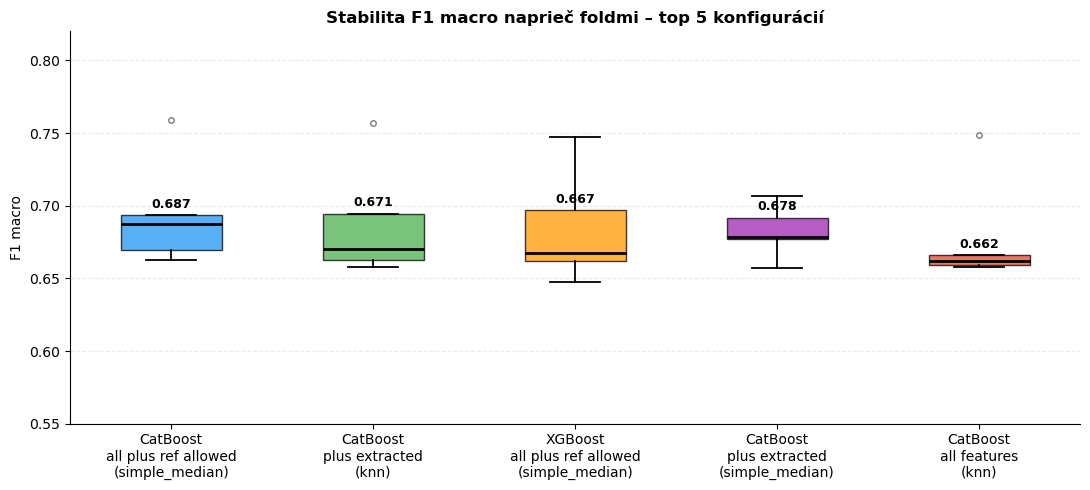

In [64]:
#  Boxplot stability foldov – top 5 konfigurácií


top5 = top_candidates_df.head(5).copy()
top5["label"] = (
    top5["model"] + "\n"
    + top5["feature_set"].str.replace("mixed_", "").str.replace("_", " ")
    + "\n(" + top5["imputation_strategy"] + ")"
)

fold_data = []
for _, row in top5.iterrows():
    mask = (
        (all_fold_results_final["model"] == row["model"]) &
        (all_fold_results_final["feature_set"] == row["feature_set"]) &
        (all_fold_results_final["imputation_strategy"] == row["imputation_strategy"])
    )
    folds = all_fold_results_final[mask]["f1_macro"].values
    fold_data.append(folds)

fig, ax = plt.subplots(figsize=(11, 5))

bp = ax.boxplot(
    fold_data,
    labels=top5["label"].values,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    flierprops=dict(marker="o", markersize=4, alpha=0.5)
)

colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, folds in enumerate(fold_data, start=1):
    med = np.median(folds)
    q3 = np.percentile(folds, 75)
    ax.text(i, q3 + 0.003, f"{med:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("F1 macro")
ax.set_ylim(0.55, 0.82)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title(
    "Stabilita F1 macro naprieč foldmi – top 5 konfigurácií",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
#plt.savefig("boxplot_stabilita_top5.png", dpi=150, bbox_inches="tight")
plt.show()

In [65]:
#  Porovnanie imputácií: simple_median vs knn


imputation_compare_df = (
    summary_all_final
    .pivot_table(
        index=["model", "feature_set", "information_type"],
        columns="imputation_strategy",
        values="f1_macro_mean",
        aggfunc="max"
    )
    .reset_index()
)

if {"simple_median", "knn"}.issubset(imputation_compare_df.columns):

    imputation_compare_df["delta_knn_minus_simple"] = (
        imputation_compare_df["knn"] - imputation_compare_df["simple_median"]
    )

    imputation_compare_summary = pd.DataFrame({
        "metric": [
            "n_porovnani",
            "knn_lepsie",
            "simple_median_lepsie_alebo_rovnake",
            "priemerny_delta_knn_minus_simple",
            "median_delta_knn_minus_simple",
            "max_delta_knn_minus_simple",
            "min_delta_knn_minus_simple"
        ],
        "value": [
            imputation_compare_df["delta_knn_minus_simple"].notna().sum(),
            (imputation_compare_df["delta_knn_minus_simple"] > 0).sum(),
            (imputation_compare_df["delta_knn_minus_simple"] <= 0).sum(),
            imputation_compare_df["delta_knn_minus_simple"].mean(),
            imputation_compare_df["delta_knn_minus_simple"].median(),
            imputation_compare_df["delta_knn_minus_simple"].max(),
            imputation_compare_df["delta_knn_minus_simple"].min()
        ]
    })

    numeric_cols = imputation_compare_df.select_dtypes(include=["number"]).columns
    imputation_compare_df[numeric_cols] = imputation_compare_df[numeric_cols].round(4)

    numeric_cols = imputation_compare_summary.select_dtypes(include=["number"]).columns
    imputation_compare_summary[numeric_cols] = imputation_compare_summary[numeric_cols].round(4)

    imputation_compare_df = imputation_compare_df.sort_values(
        "delta_knn_minus_simple",
        ascending=False
    ).reset_index(drop=True)

    display(imputation_compare_summary)
    display(imputation_compare_df.head(20))

else:
    print("V dátach nie sú obe imputácie: simple_median a knn.")

,metric,value
0,n_porovnani,56.0000
1,knn_lepsie,13.0000
2,simple_median_lepsie_alebo_rovnake,43.0000
3,priemerny_delta_knn_minus_simple,-0.0100
4,median_delta_knn_minus_simple,-0.0058
5,max_delta_knn_minus_simple,0.0162
6,min_delta_knn_minus_simple,-0.0487


imputation_strategy,model,feature_set,information_type,knn,simple_median,delta_knn_minus_simple
0,HistGradientBoosting,mixed_plus_ref_allowed,mixed,0.6378,0.6216,0.0162
1,RandomForest,first_all_features,admission,0.4120,0.3984,0.0136
2,CatBoost,first_all_plus_ref_allowed,admission,0.5445,0.5316,0.0129
3,XGBoost,first_plus_extracted,admission,0.5398,0.5303,0.0095
4,CatBoost,mixed_plus_extracted,mixed,0.6886,0.6823,0.0063
5,HistGradientBoosting,first_plus_indexes,admission,0.5154,0.5095,0.0059
6,XGBoost,mixed_plus_ref_allowed,mixed,0.6559,0.6521,0.0038
7,CatBoost,first_plus_ref_allowed,admission,0.5209,0.5172,0.0037
8,RandomForest,first_plus_indexes,admission,0.4039,0.4016,0.0023
9,RandomForest,first_plus_extracted,admission,0.3862,0.3848,0.0014


In [66]:
#  Wilcoxon testy na fold-level výsledkoch

from scipy.stats import wilcoxon

wilcoxon_results = []

def run_wilcoxon_from_paired_df(
    df,
    value_col,
    group_col,
    group_a,
    group_b,
    pair_cols,
    comparison_name
):
    tmp = df[df[group_col].isin([group_a, group_b])].copy()

    pivot = (
        tmp
        .pivot_table(
            index=pair_cols,
            columns=group_col,
            values=value_col,
            aggfunc="mean"
        )
        .dropna()
    )

    if group_a not in pivot.columns or group_b not in pivot.columns:
        print(f"Chýba skupina pri porovnaní: {comparison_name}")
        return None

    if len(pivot) < 2:
        print(f"Málo párov pre Wilcoxon test: {comparison_name}")
        return None

    diff = pivot[group_b] - pivot[group_a]

    try:
        stat, p_value = wilcoxon(
            pivot[group_a],
            pivot[group_b],
            zero_method="wilcox",
            alternative="two-sided"
        )
    except ValueError as e:
        print(f"Wilcoxon problém pri {comparison_name}: {e}")
        stat, p_value = np.nan, np.nan

    return {
        "comparison": comparison_name,
        "metric": value_col,
        "group_a": group_a,
        "group_b": group_b,
        "n_pairs": len(pivot),
        "mean_group_a": pivot[group_a].mean(),
        "mean_group_b": pivot[group_b].mean(),
        "mean_diff_b_minus_a": diff.mean(),
        "median_diff_b_minus_a": diff.median(),
        "wilcoxon_stat": stat,
        "p_value": p_value
    }


# 5.1 simple_median vs knn
# ------------------------------------------------------------

pair_cols_imputation = [
    "dataset_subset",
    "experiment_group",
    "target",
    "model",
    "feature_set",
    "fold"
]

pair_cols_imputation = [
    col for col in pair_cols_imputation
    if col in all_fold_results_final.columns
]

res = run_wilcoxon_from_paired_df(
    df=all_fold_results_final,
    value_col="f1_macro",
    group_col="imputation_strategy",
    group_a="simple_median",
    group_b="knn",
    pair_cols=pair_cols_imputation,
    comparison_name="simple_median_vs_knn"
)

if res is not None:
    wilcoxon_results.append(res)



# 5.2 Najlepšie dva modely podľa max F1 macro
# ------------------------------------------------------------

top_models = (
    summary_all_final
    .groupby("model")["f1_macro_mean"]
    .max()
    .sort_values(ascending=False)
    .head(2)
    .index
    .tolist()
)

if len(top_models) == 2:

    pair_cols_model = [
        "dataset_subset",
        "experiment_group",
        "target",
        "feature_set",
        "imputation_strategy",
        "fold"
    ]

    pair_cols_model = [
        col for col in pair_cols_model
        if col in all_fold_results_final.columns
    ]

    res = run_wilcoxon_from_paired_df(
        df=all_fold_results_final,
        value_col="f1_macro",
        group_col="model",
        group_a=top_models[1],
        group_b=top_models[0],
        pair_cols=pair_cols_model,
        comparison_name=f"{top_models[0]}_vs_{top_models[1]}"
    )

    if res is not None:
        wilcoxon_results.append(res)



# 5.3 Baseline vs najlepší feature set
# ------------------------------------------------------------

best_feature_set = (
    summary_all_final
    .groupby("feature_set")["f1_macro_mean"]
    .max()
    .sort_values(ascending=False)
    .index[0]
)

baseline_candidates = [
    fs for fs in summary_all_final["feature_set"].unique()
    if "baseline" in str(fs).lower()
]

if len(baseline_candidates) > 0:

    baseline_feature_set = baseline_candidates[0]

    pair_cols_feature = [
        "dataset_subset",
        "experiment_group",
        "target",
        "model",
        "imputation_strategy",
        "fold"
    ]

    pair_cols_feature = [
        col for col in pair_cols_feature
        if col in all_fold_results_final.columns
    ]

    res = run_wilcoxon_from_paired_df(
        df=all_fold_results_final,
        value_col="f1_macro",
        group_col="feature_set",
        group_a=baseline_feature_set,
        group_b=best_feature_set,
        pair_cols=pair_cols_feature,
        comparison_name=f"{best_feature_set}_vs_{baseline_feature_set}"
    )

    if res is not None:
        wilcoxon_results.append(res)

wilcoxon_results_df = pd.DataFrame(wilcoxon_results)

if not wilcoxon_results_df.empty:
    numeric_cols = wilcoxon_results_df.select_dtypes(include=["number"]).columns
    wilcoxon_results_df[numeric_cols] = wilcoxon_results_df[numeric_cols].round(5)

wilcoxon_results_df

,comparison,metric,group_a,group_b,n_pairs,mean_group_a,mean_group_b,mean_diff_b_minus_a,median_diff_b_minus_a,wilcoxon_stat,p_value
0,simple_median_vs_knn,f1_macro,simple_median,knn,280,0.55098,0.54102,-0.00997,-0.00573,8765.0,0.0000
1,CatBoost_vs_XGBoost,f1_macro,XGBoost,CatBoost,140,0.57827,0.59081,0.01254,0.01188,2688.0,0.0000
2,mixed_all_plus_ref_allowed_vs_baseline_mixed,f1_macro,baseline_mixed,mixed_all_plus_ref_allowed,40,0.62174,0.62519,0.00345,0.00406,341.0,0.3611


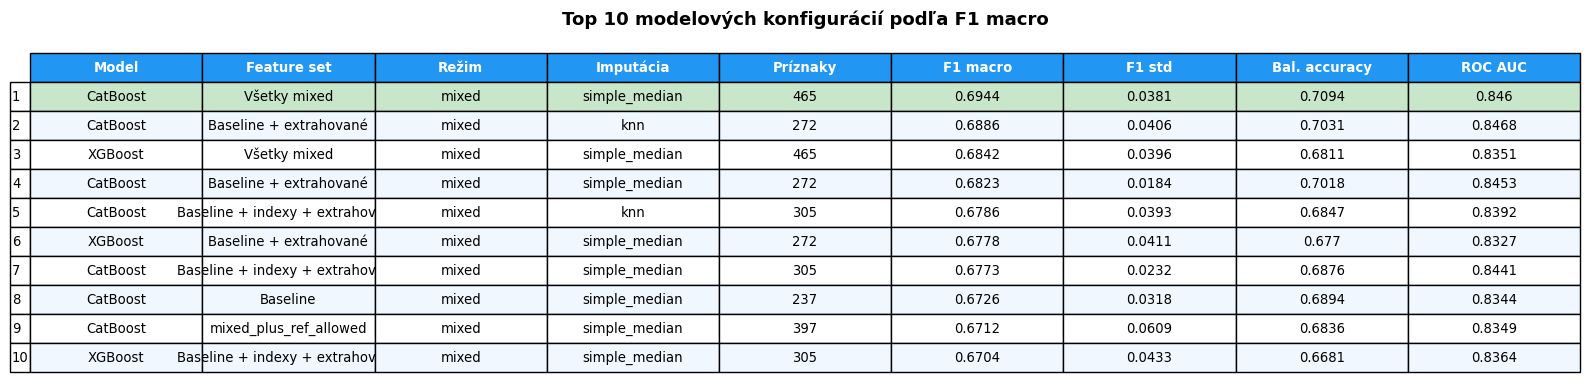

In [67]:
#  Tabuľka top 10 konfigurácií – vizualizácia


display_cols = {
    "model":                 "Model",
    "feature_set":           "Feature set",
    "information_type":      "Režim",
    "imputation_strategy":   "Imputácia",
    "n_features":            "Príznaky",
    "f1_macro_mean":         "F1 macro",
    "f1_macro_std":          "F1 std",
    "balanced_accuracy_mean":"Bal. accuracy",
    "roc_auc_mean":          "ROC AUC",
}

feature_set_labels = {
    "baseline_first_only":        "Baseline",
    "first_plus_indexes":         "Baseline + indexy",
    "first_plus_extracted":       "Baseline + extrahované",
    "first_all_features":         "Baseline + indexy + extrahované",
    "first_all_plus_ref_allowed": "Všetky admission",
    "baseline_mixed":             "Baseline",
    "mixed_plus_indexes":         "Baseline + indexy",
    "mixed_plus_extracted":       "Baseline + extrahované",
    "mixed_all_features":         "Baseline + indexy + extrahované",
    "mixed_all_plus_ref_allowed": "Všetky mixed",
}

top10 = top_candidates_df.head(10).copy()
top10["feature_set"] = top10["feature_set"].map(
    lambda x: feature_set_labels.get(x, x)
)
top10["f1_macro_mean"]          = top10["f1_macro_mean"].round(4)
top10["f1_macro_std"]           = top10["f1_macro_std"].round(4)
top10["balanced_accuracy_mean"] = top10["balanced_accuracy_mean"].round(4)
top10["roc_auc_mean"]           = top10["roc_auc_mean"].round(4)
top10.index = range(1, 11)

top10_display = top10[list(display_cols.keys())].rename(columns=display_cols)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")

table = ax.table(
    cellText=top10_display.values,
    colLabels=top10_display.columns,
    rowLabels=top10_display.index,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.6)

# Hlavička
for j in range(len(top10_display.columns)):
    table[0, j].set_facecolor("#2196F3")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Striedavé riadky
for i in range(1, 11):
    color = "#f0f7ff" if i % 2 == 0 else "white"
    for j in range(len(top10_display.columns)):
        table[i, j].set_facecolor(color)

# Zvýrazniť najlepší riadok
for j in range(len(top10_display.columns)):
    table[1, j].set_facecolor("#c8e6c9")

plt.title("Top 10 modelových konfigurácií podľa F1 macro",
          fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
#plt.savefig("top10_konfiguracie.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
#  95 % intervaly spoľahlivosti pre top kandidátov


from scipy.stats import t

ci_rows = []

for _, row in top_candidates_df.iterrows():

    mask = (
        (all_fold_results_final["model"] == row["model"]) &
        (all_fold_results_final["feature_set"] == row["feature_set"]) &
        (all_fold_results_final["imputation_strategy"] == row["imputation_strategy"])
    )

    if "target" in all_fold_results_final.columns and "target" in row.index:
        mask = mask & (all_fold_results_final["target"] == row["target"])

    fold_df = all_fold_results_final[mask].copy()

    values = fold_df["f1_macro"].dropna().values
    n = len(values)

    if n >= 2:
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1)
        se = std_val / np.sqrt(n)
        t_crit = t.ppf(0.975, df=n - 1)

        ci_lower = mean_val - t_crit * se
        ci_upper = mean_val + t_crit * se

    elif n == 1:
        mean_val = values[0]
        std_val = np.nan
        ci_lower = np.nan
        ci_upper = np.nan

    else:
        mean_val = np.nan
        std_val = np.nan
        ci_lower = np.nan
        ci_upper = np.nan

    ci_rows.append({
        "model": row["model"],
        "feature_set": row["feature_set"],
        "imputation_strategy": row["imputation_strategy"],
        "n_folds": n,
        "f1_macro_mean": mean_val,
        "f1_macro_std": std_val,
        "f1_macro_ci95_lower": ci_lower,
        "f1_macro_ci95_upper": ci_upper
    })

top_candidates_ci_df = pd.DataFrame(ci_rows)

numeric_cols = top_candidates_ci_df.select_dtypes(include=["number"]).columns
top_candidates_ci_df[numeric_cols] = top_candidates_ci_df[numeric_cols].round(4)

top_candidates_ci_df.sort_values(
    "f1_macro_mean",
    ascending=False
)

,model,feature_set,imputation_strategy,n_folds,f1_macro_mean,f1_macro_std,f1_macro_ci95_lower,f1_macro_ci95_upper
0,CatBoost,mixed_all_plus_ref_allowed,simple_median,5,0.6944,0.0381,0.6471,0.7416
1,CatBoost,mixed_plus_extracted,knn,5,0.6886,0.0406,0.6381,0.7391
2,XGBoost,mixed_all_plus_ref_allowed,simple_median,5,0.6842,0.0396,0.6350,0.7333
3,CatBoost,mixed_plus_extracted,simple_median,5,0.6823,0.0184,0.6595,0.7052
4,CatBoost,mixed_all_features,knn,5,0.6786,0.0393,0.6298,0.7274
5,XGBoost,mixed_plus_extracted,simple_median,5,0.6778,0.0411,0.6268,0.7288
6,CatBoost,mixed_all_features,simple_median,5,0.6773,0.0232,0.6485,0.7061
7,CatBoost,baseline_mixed,simple_median,5,0.6726,0.0318,0.6331,0.7121
8,CatBoost,mixed_plus_ref_allowed,simple_median,5,0.6712,0.0609,0.5956,0.7467
9,XGBoost,mixed_all_features,simple_median,5,0.6704,0.0433,0.6166,0.7242


In [69]:
#  Export evaluačných tabuliek do Excelu



OUTPUT_EXCEL = "Výsledky_wave4_target3.xlsx"

eval_exports = {
    "top_candidates": top_candidates_df,
    "fold_stability_top": fold_stability_top_df,
    "top_candidate_folds": top_candidate_fold_results_df,
    "imputation_compare": imputation_compare_df if "imputation_compare_df" in globals() else pd.DataFrame(),
    "imputation_compare_sum": imputation_compare_summary if "imputation_compare_summary" in globals() else pd.DataFrame(),
    "wilcoxon_tests": wilcoxon_results_df if "wilcoxon_results_df" in globals() else pd.DataFrame(),
    "top_candidates_ci": top_candidates_ci_df if "top_candidates_ci_df" in globals() else pd.DataFrame(),
    "classification_reports": classification_reports_df if "classification_reports_df" in globals() else pd.DataFrame()
}

if os.path.exists(OUTPUT_EXCEL):
    with pd.ExcelWriter(
        OUTPUT_EXCEL,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        for sheet_name, df_export in eval_exports.items():
            if df_export is not None and not df_export.empty:
                df_export.to_excel(
                    writer,
                    sheet_name=sheet_name[:31],
                    index=False
                )
else:
    with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
        for sheet_name, df_export in eval_exports.items():
            if df_export is not None and not df_export.empty:
                df_export.to_excel(
                    writer,
                    sheet_name=sheet_name[:31],
                    index=False
                )

print(f"Evaluačné tabuľky exportované do: {OUTPUT_EXCEL}")

Evaluačné tabuľky exportované do: Výsledky_wave4_target3.xlsx


In [70]:
best_row = top_candidates_df.iloc[0]

print("Najlepší kandidát podľa F1 macro:")
print(f"Model: {best_row['model']}")
print(f"Feature set: {best_row['feature_set']}")
print(f"Imputácia: {best_row['imputation_strategy']}")
print(f"F1 macro: {best_row['f1_macro_mean']:.4f}")
print(f"Balanced accuracy: {best_row['balanced_accuracy_mean']:.4f}")
print(f"ROC AUC: {best_row['roc_auc_mean']:.4f}")

if "imputation_compare_summary" in globals():
    print("\nPorovnanie imputácií:")
    display(imputation_compare_summary)

if "wilcoxon_results_df" in globals() and not wilcoxon_results_df.empty:
    print("\nWilcoxon testy:")
    display(wilcoxon_results_df)

Najlepší kandidát podľa F1 macro:
Model: CatBoost
Feature set: mixed_all_plus_ref_allowed
Imputácia: simple_median
F1 macro: 0.6944
Balanced accuracy: 0.7094
ROC AUC: 0.8460

Porovnanie imputácií:


,metric,value
0,n_porovnani,56.0000
1,knn_lepsie,13.0000
2,simple_median_lepsie_alebo_rovnake,43.0000
3,priemerny_delta_knn_minus_simple,-0.0100
4,median_delta_knn_minus_simple,-0.0058
5,max_delta_knn_minus_simple,0.0162
6,min_delta_knn_minus_simple,-0.0487



Wilcoxon testy:


,comparison,metric,group_a,group_b,n_pairs,mean_group_a,mean_group_b,mean_diff_b_minus_a,median_diff_b_minus_a,wilcoxon_stat,p_value
0,simple_median_vs_knn,f1_macro,simple_median,knn,280,0.55098,0.54102,-0.00997,-0.00573,8765.0,0.0000
1,CatBoost_vs_XGBoost,f1_macro,XGBoost,CatBoost,140,0.57827,0.59081,0.01254,0.01188,2688.0,0.0000
2,mixed_all_plus_ref_allowed_vs_baseline_mixed,f1_macro,baseline_mixed,mixed_all_plus_ref_allowed,40,0.62174,0.62519,0.00345,0.00406,341.0,0.3611
